In [511]:
import numpy as np
import matplotlib.pyplot as plt
import math

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import lib_plot


from lib_equations import root_finder, herm_coeff, herm_func, trapezoidal, Simpson


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


H_6(x) =  -120 + 720x^2 - 480x^4 + 64x^6


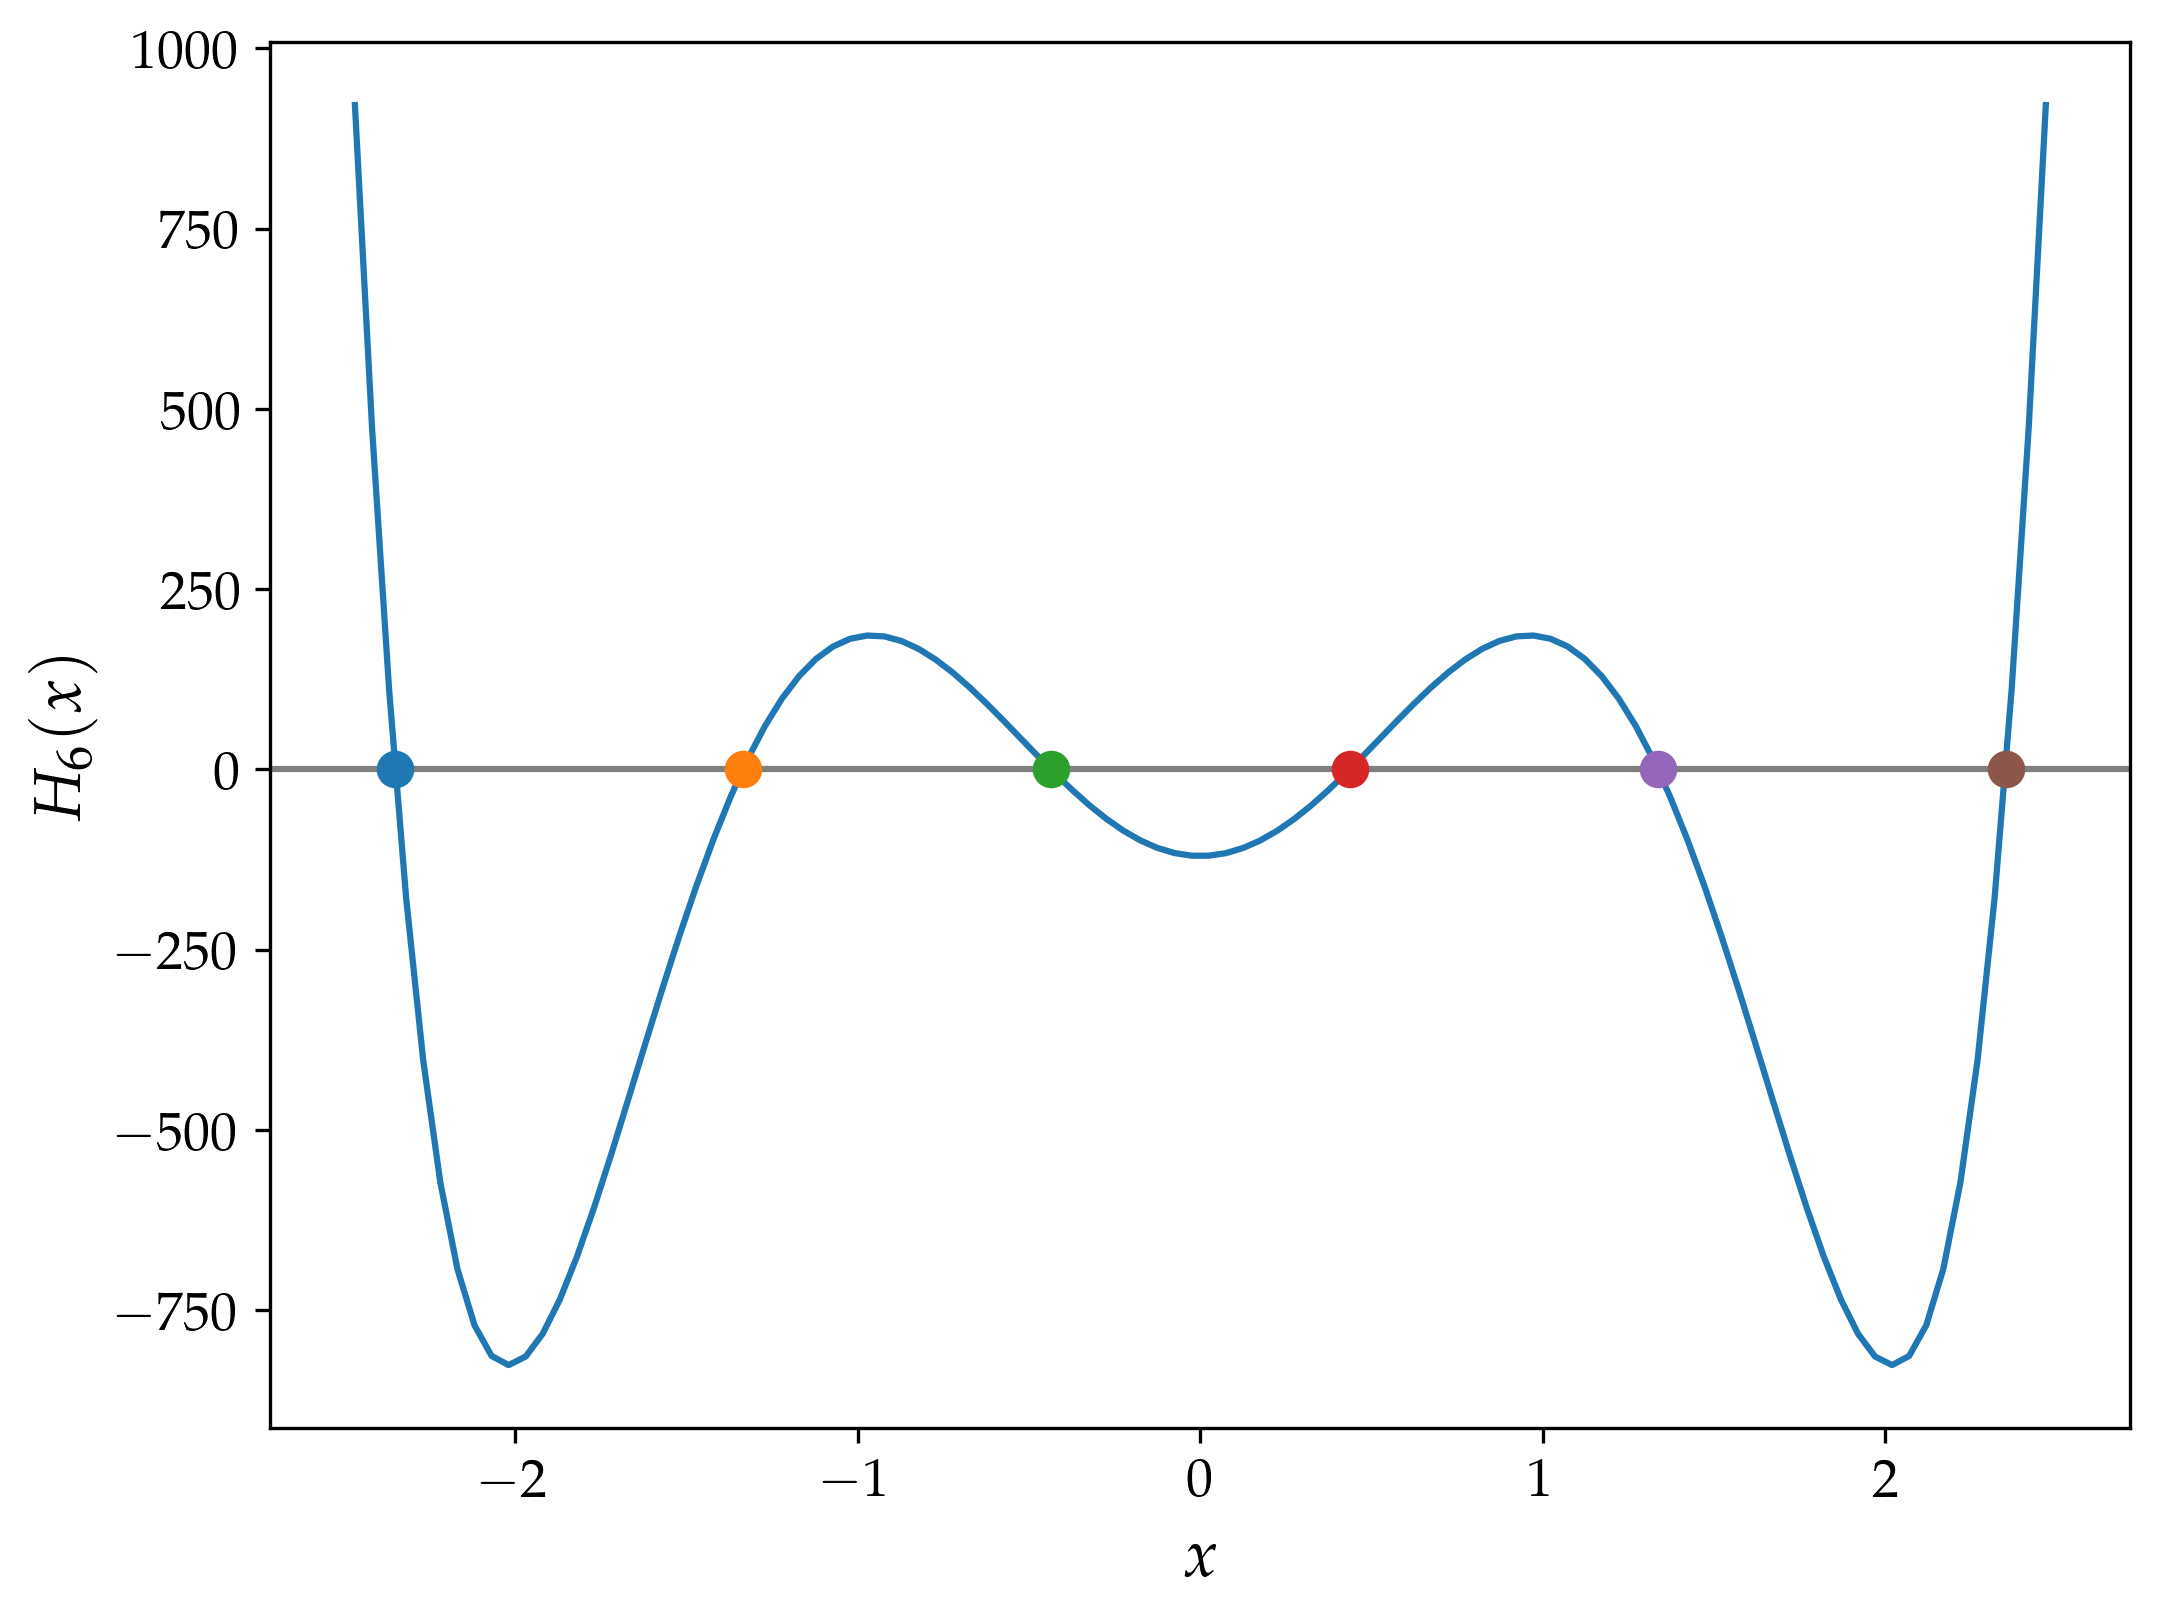

In [512]:
deg = 6
H_coeff = np.flip(herm_coeff(deg))
H_roots = root_finder(herm_coeff(deg))

coeffs = H_coeff
terms = []
for i, c in enumerate(coeffs):
    if np.isclose(c, 0):
        continue
    coeff = int(c) if np.isclose(c, round(c)) else float(c)
    sign = "+" if c > 0 else "-"
    abs_coeff = abs(coeff)
    if i == 0:
        term = f"{abs_coeff}"
    elif i == 1:
        term = f"{abs_coeff}x"
    else:
        term = f"{abs_coeff}x^{i}"
    if terms:
        terms.append(f" {sign} {term}")
    else:
        terms.append(f"{'-' if c < 0 else ''}{term}")
poly_str = "".join(terms) if terms else "0"
print(f'H_{deg}(x) = ', poly_str)

limx = max(H_roots)*1.05
xcoo = np.linspace(-limx, limx, 100, dtype=float)
ycoo = herm_func(xcoo, deg)

plt.plot(xcoo, ycoo)
for i, root in enumerate(H_roots):
    plt.scatter(root, 0, marker='o', zorder=3, lw=3, label=rf'$x_{i}$')

plt.axhline(color='black', alpha=0.5)
plt.ylim()

plt.xlabel(rf'$x$')
plt.ylabel(rf'$H_{deg}(x)$')
# plt.legend()
plt.show()



In [513]:
from first_ex import deg

data = np.genfromtxt('txts/res_test_gauss.txt')

xcoo_load, ycoo_load = (data[:-1, :][:, 0], data[:-1, :][:, 1])
res = data[-1, 0]

print(f'Result (n={deg}) = ', res)


Result (n=15) =  1.3435274681307219


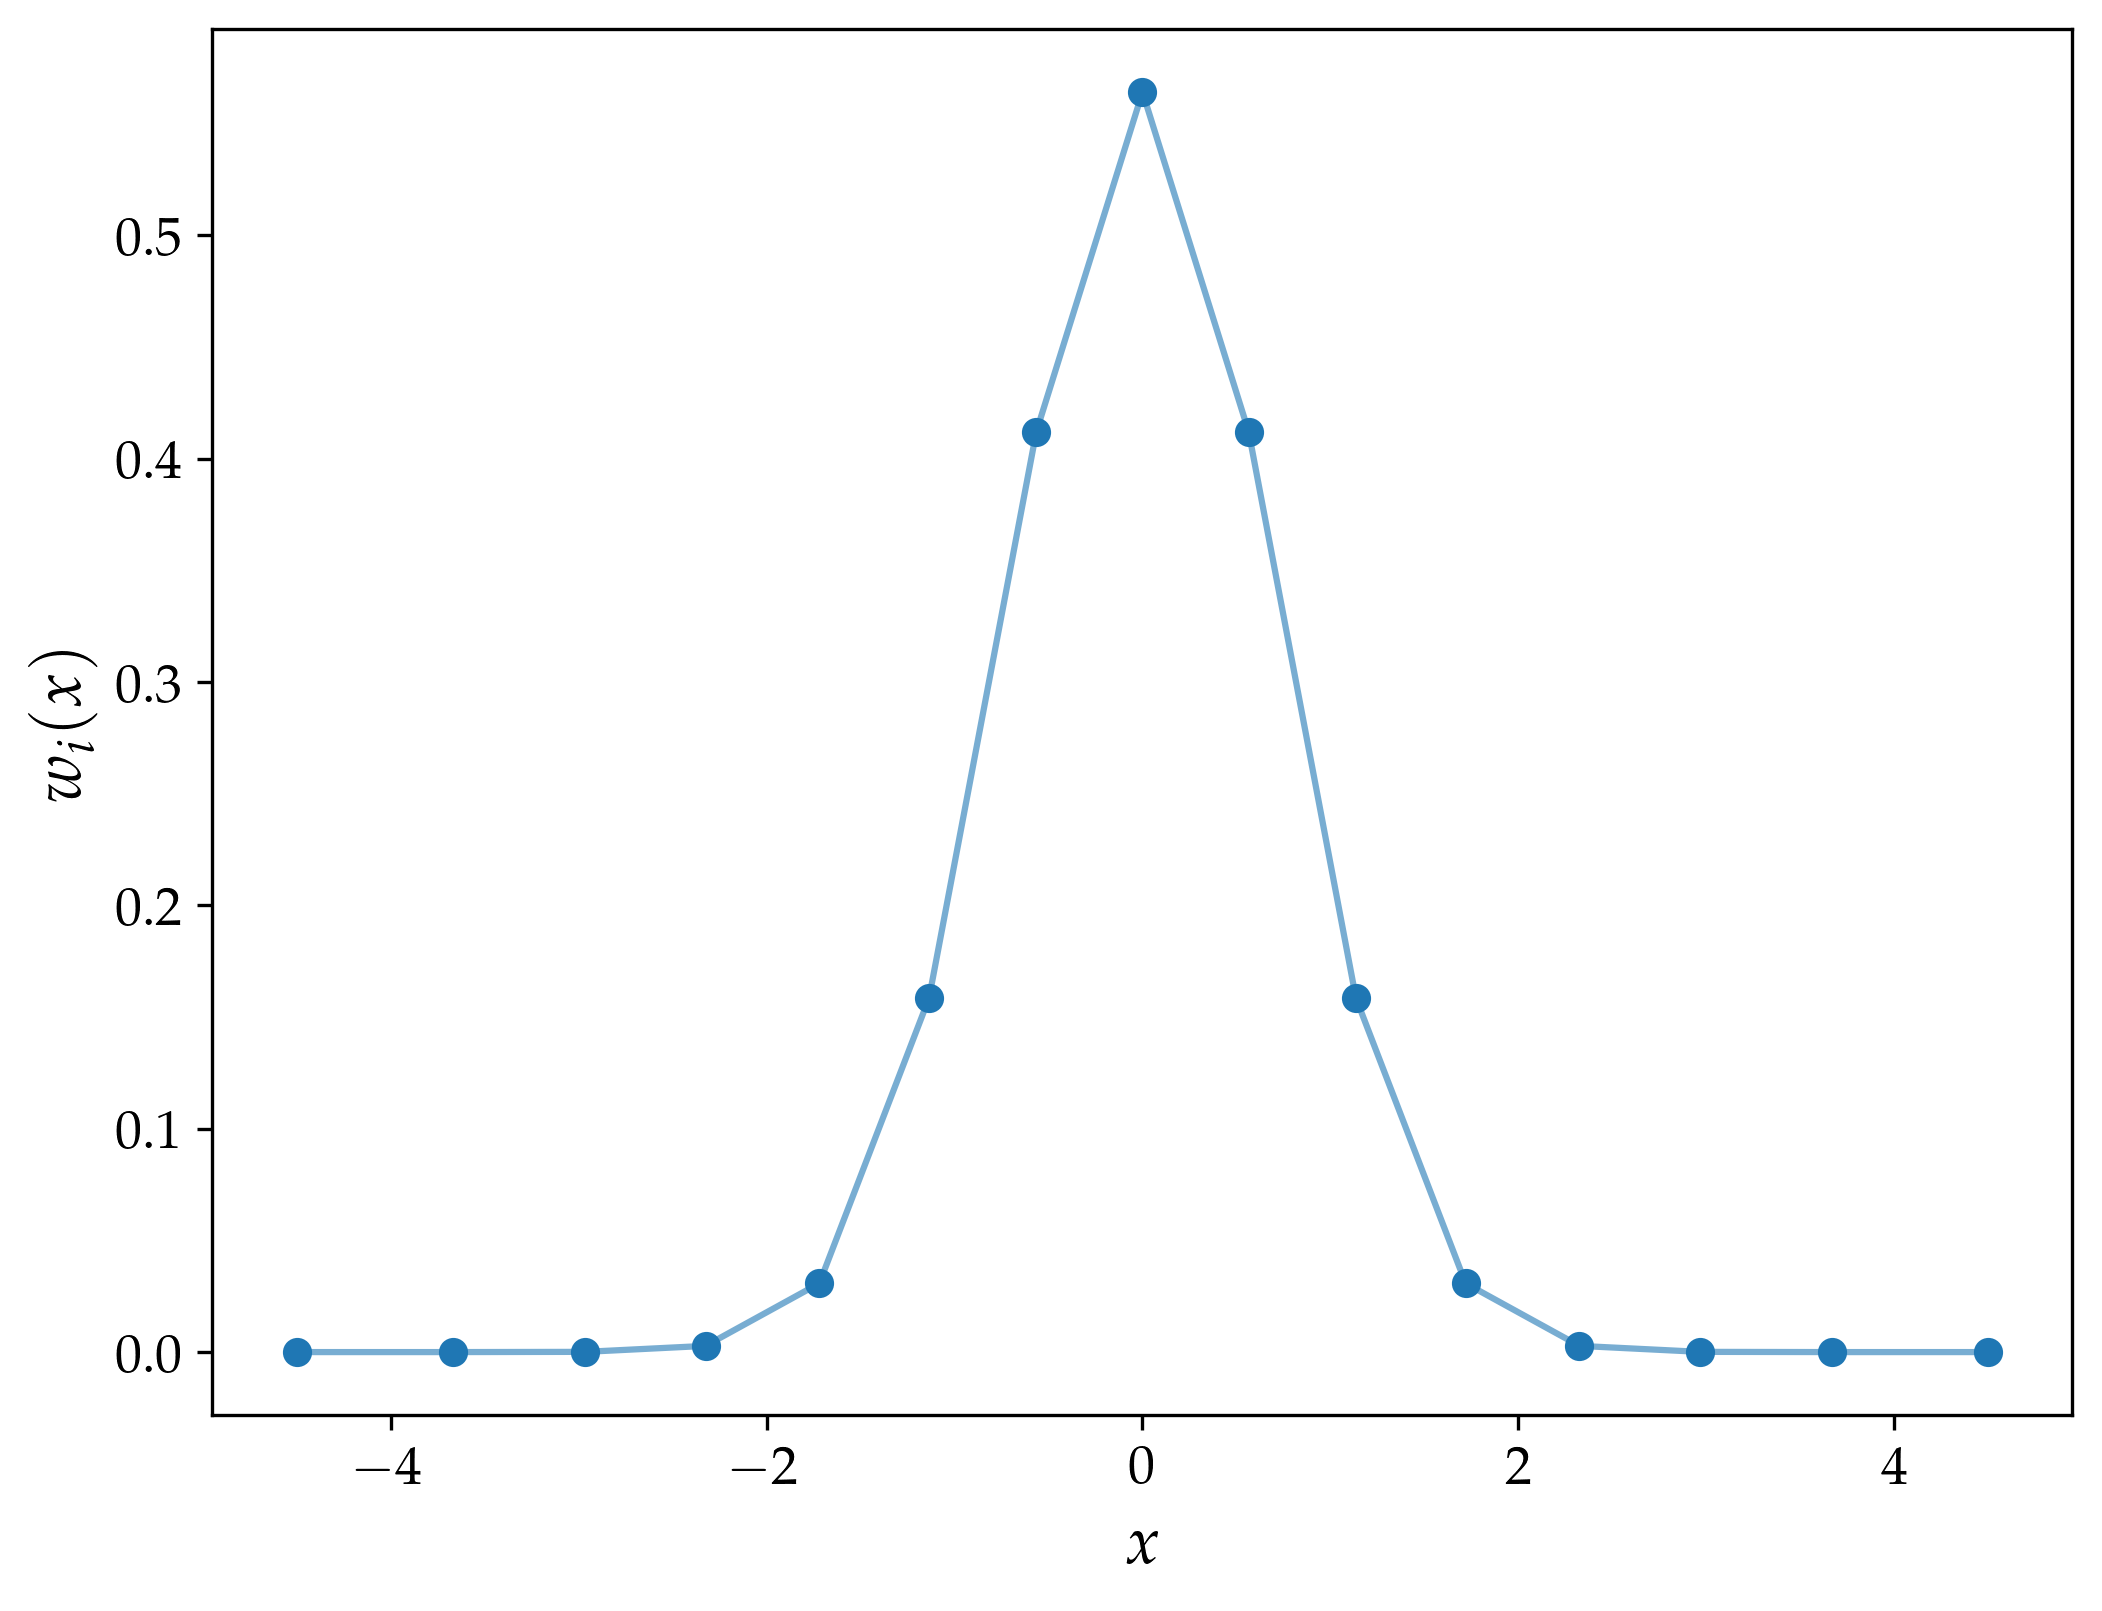

In [514]:

plt.plot(xcoo_load, ycoo_load, alpha=0.6)
plt.scatter(xcoo_load, ycoo_load, zorder=3, label='Radici ')
plt.xlabel(r'$x$')
plt.ylabel(rf'$w_i(x)$')

plt.savefig('plots/width_example.png')
plt.show()


# **Int_1**

In [515]:
data = np.loadtxt('txts/int1.txt')
from int_1 import n_deg_1
errs_1 = data[:, 2]

print('n --> res:')
for row in data:
    deg, res, err = row
    if deg < 10:
        print(f'    {int(deg)}  -->   {res}')
    else:
        print(f'    {int(deg)} -->   {res}')
    print(f'       -->   {err:.1e}\n')

n --> res:
    1  -->   1.7724538509055159
       -->   4.3e-01

    3  -->   1.3134652044731012
       -->   3.0e-02

    5  -->   1.2600697486876007
       -->   8.3e-02

    7  -->   1.2540684333090661
       -->   8.9e-02

    9  -->   1.2533981815781317
       -->   9.0e-02

    11 -->   1.2533234923676781
       -->   9.0e-02

    13 -->   1.2533151780728524
       -->   9.0e-02

    15 -->   1.2517206895604847
       -->   9.2e-02

    17 -->   1.253314150187605
       -->   9.0e-02

    19 -->   -0.00023138846272612108
       -->   1.3e+00

    21 -->   4.240395835601159e-06
       -->   1.3e+00



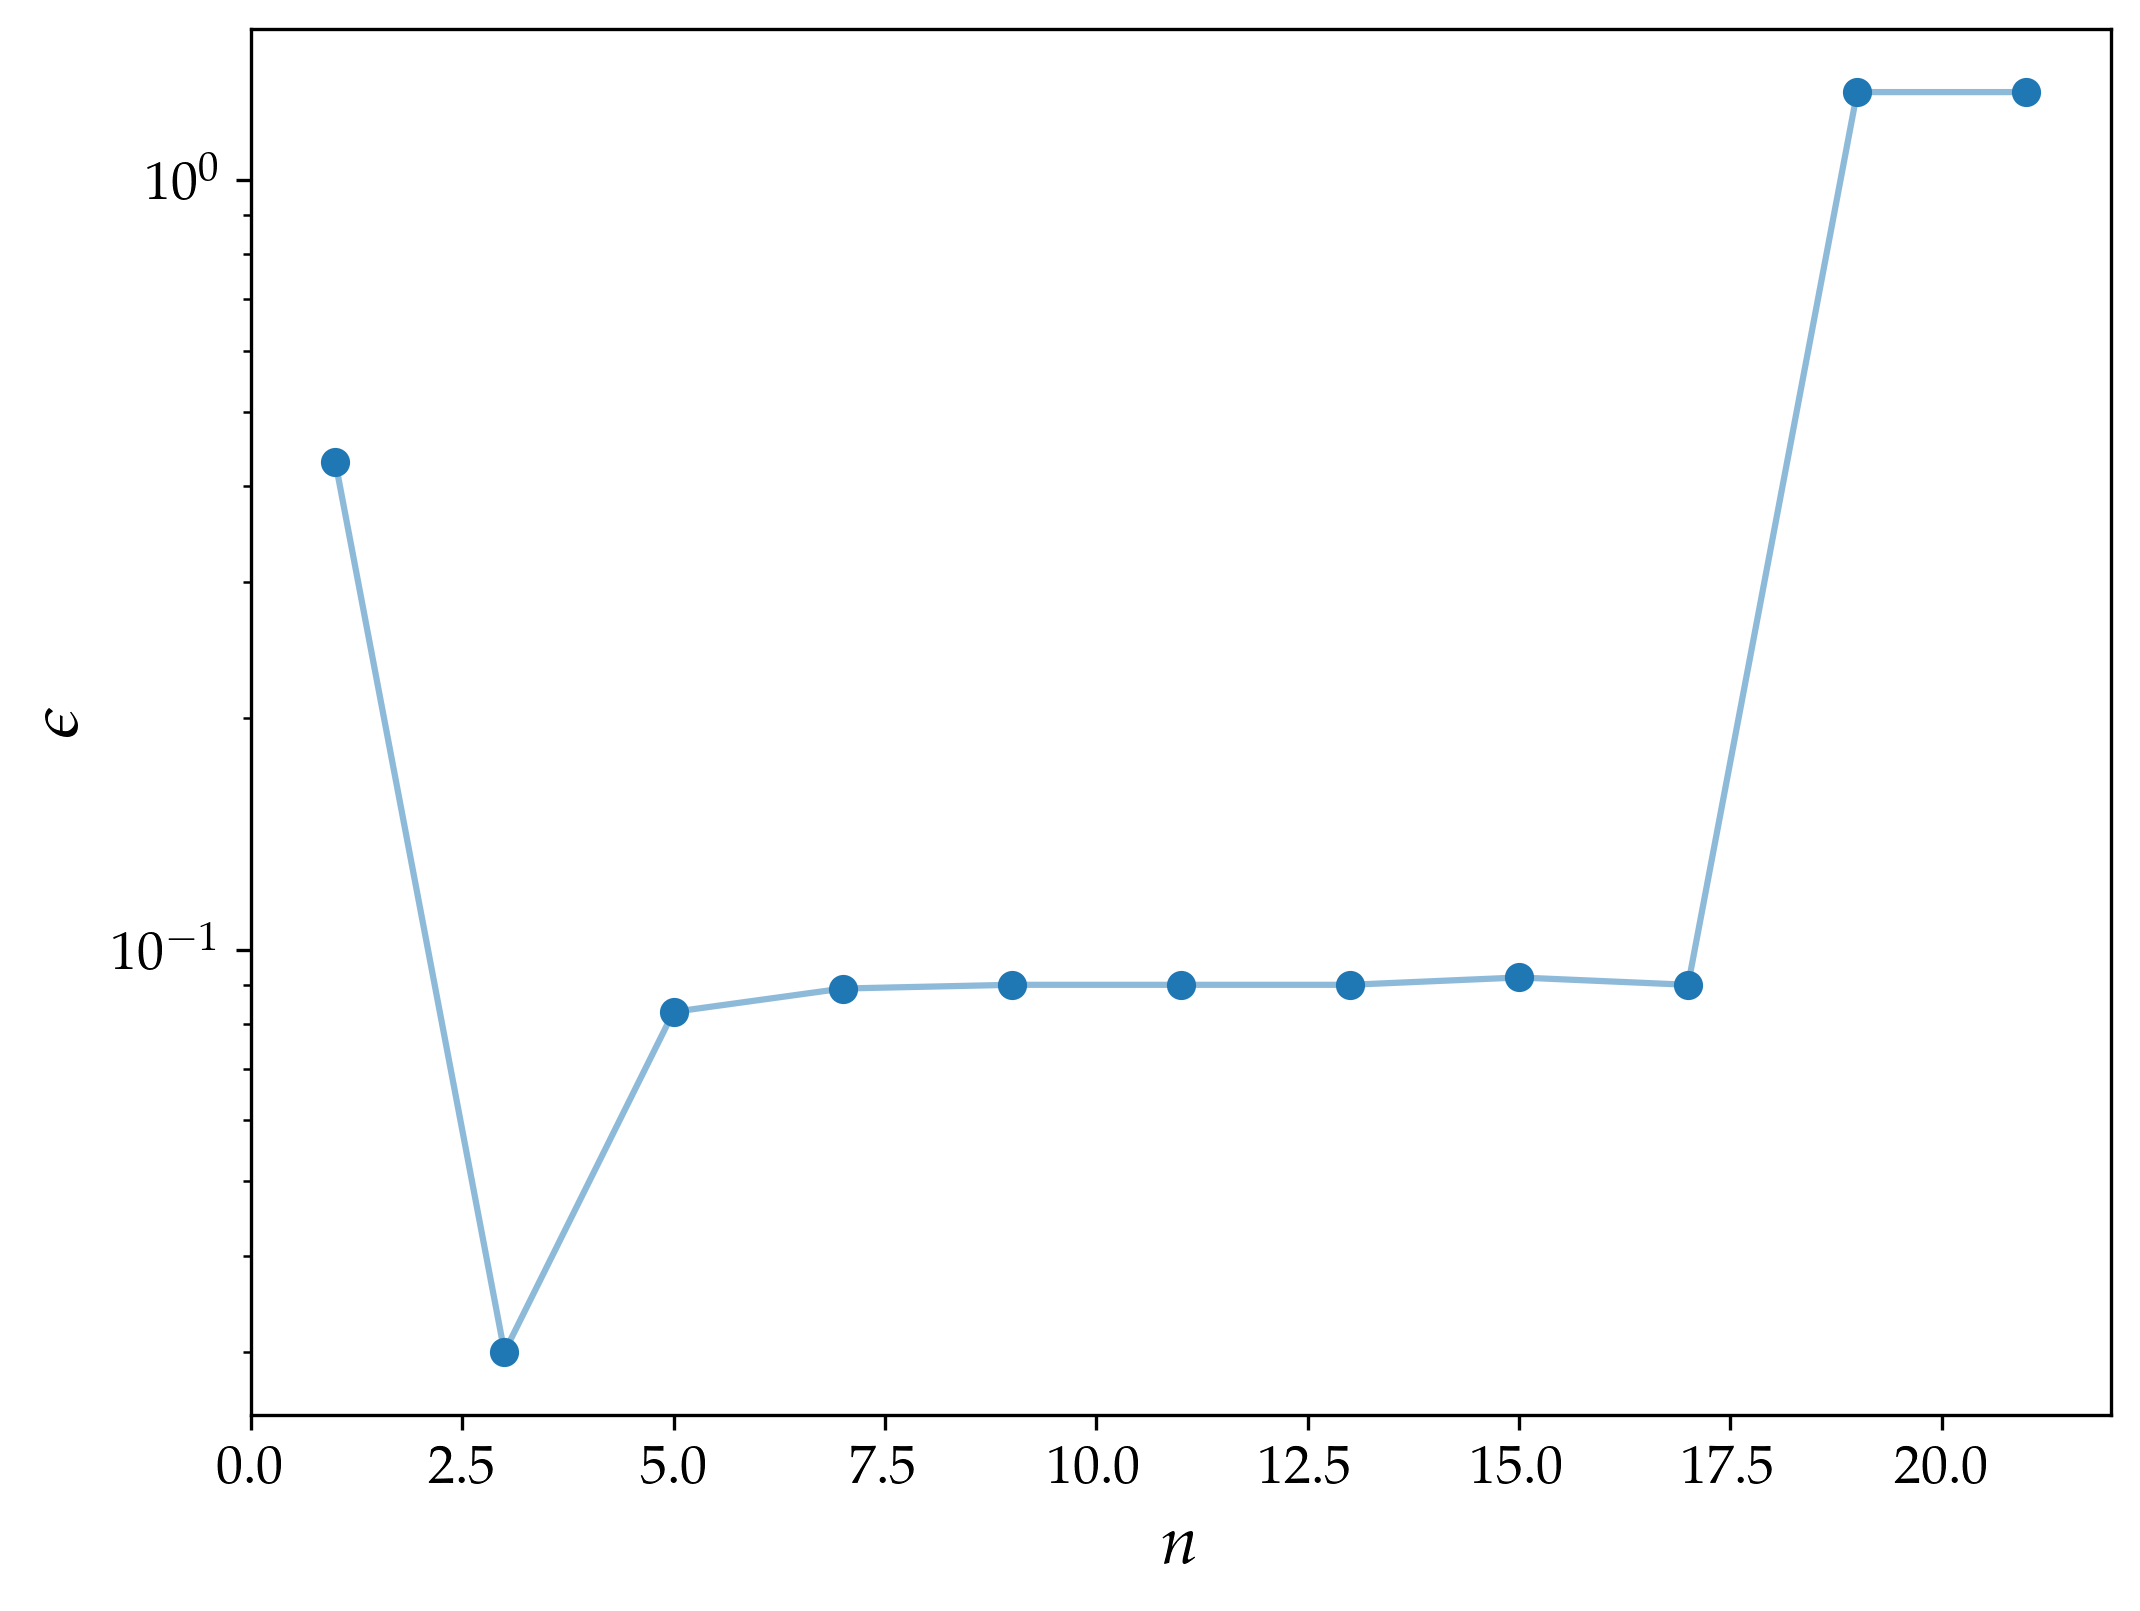

In [516]:
plt.plot(n_deg_1, errs_1, alpha=0.5)
plt.scatter(n_deg_1, errs_1)
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

plt.savefig('plots/int_1.png')
plt.show()


# **Int_2**

n --> res:
    1  -->   0.0
       -->   5.8e+00

    3  -->   1.4955079367015227
       -->   4.3e+00

    5  -->   10.31599263303481
       -->   4.5e+00

    7  -->   5.8158641982835775
       -->   1.5e-13

    9  -->   5.815864198281439
       -->   2.3e-12

    11 -->   5.815864198285083
       -->   1.4e-12

    13 -->   5.815864197710478
       -->   5.7e-10

    15 -->   5.81586417723752
       -->   2.1e-08

    17 -->   5.7967282793981205
       -->   1.9e-02

    19 -->   -0.0010737323023910623
       -->   5.8e+00

    21 -->   5.0566921528150206e-05
       -->   5.8e+00



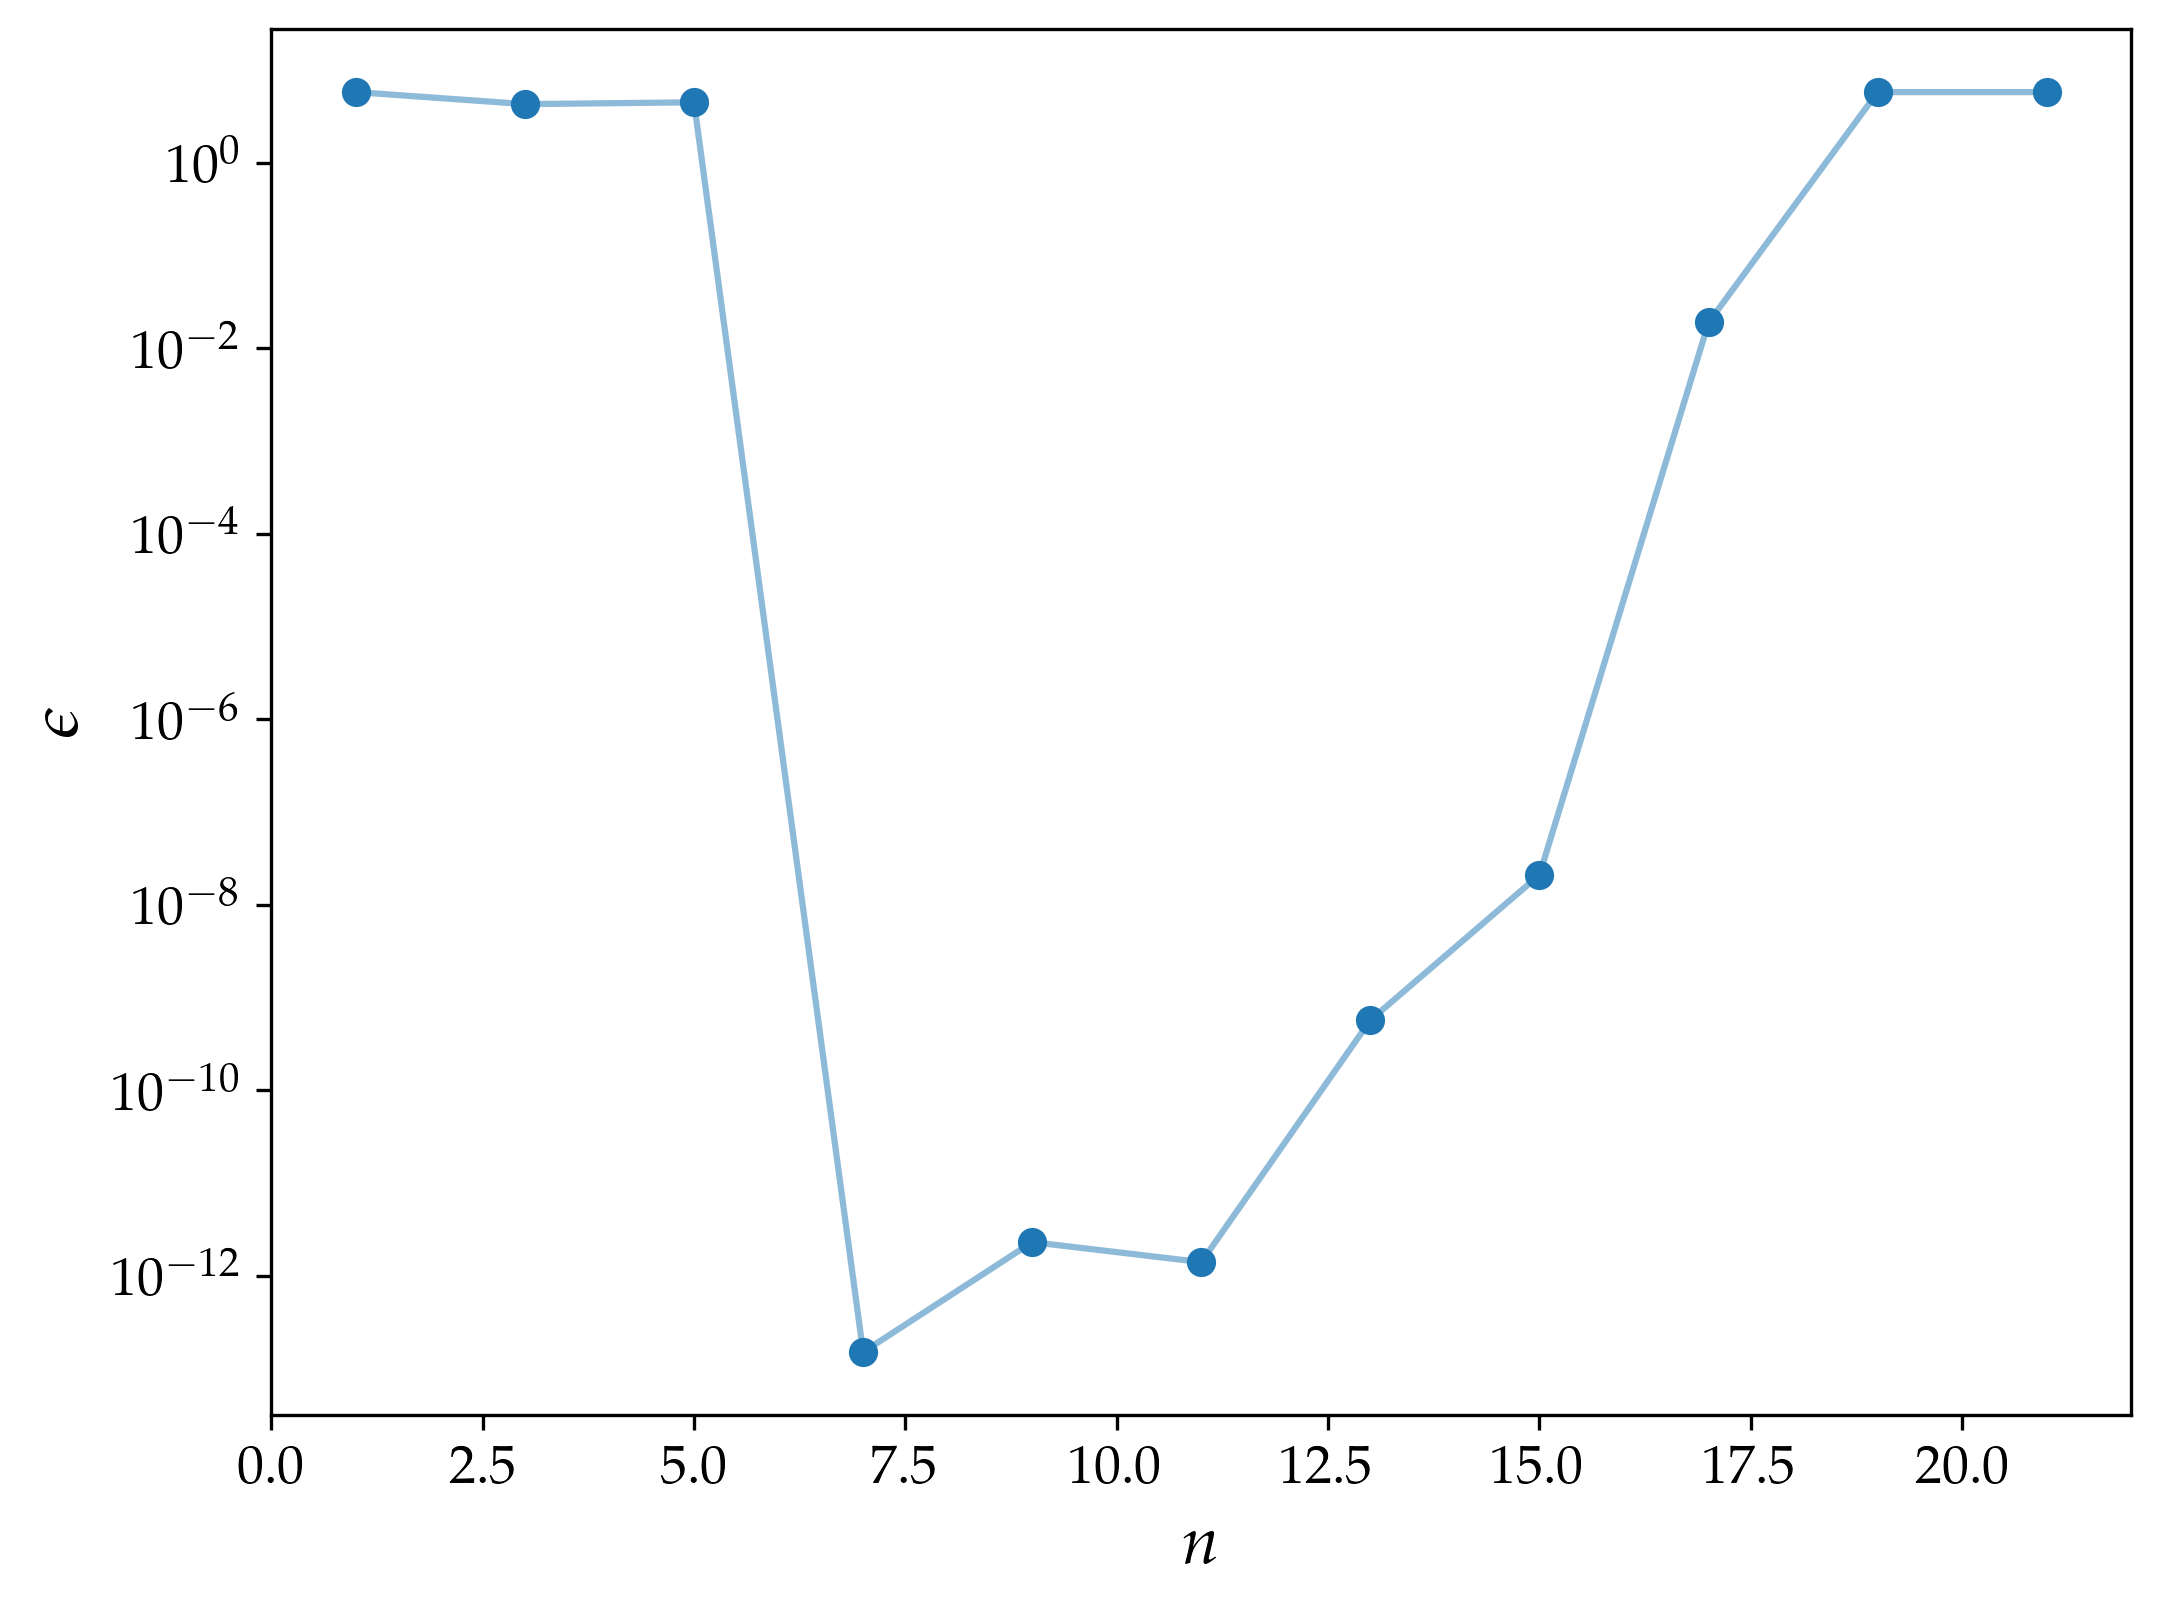

In [517]:
data = np.loadtxt('txts/int2.txt')
from int_2 import n_deg_2
errs_2 = data[:, 2]

print('n --> res:')
for row in data:
    deg, res, err = row
    if deg < 10:
        print(f'    {int(deg)}  -->   {res}')
    else:
        print(f'    {int(deg)} -->   {res}')
    print(f'       -->   {err:.1e}\n')



plt.plot(n_deg_2, errs_2, alpha=0.5)
plt.scatter(n_deg_2, errs_2)
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

plt.savefig('plots/int_2.png')
plt.show()


## **The case of interest of $\int_3 ^\infty dx\ x^5 e^{-x^2}$**

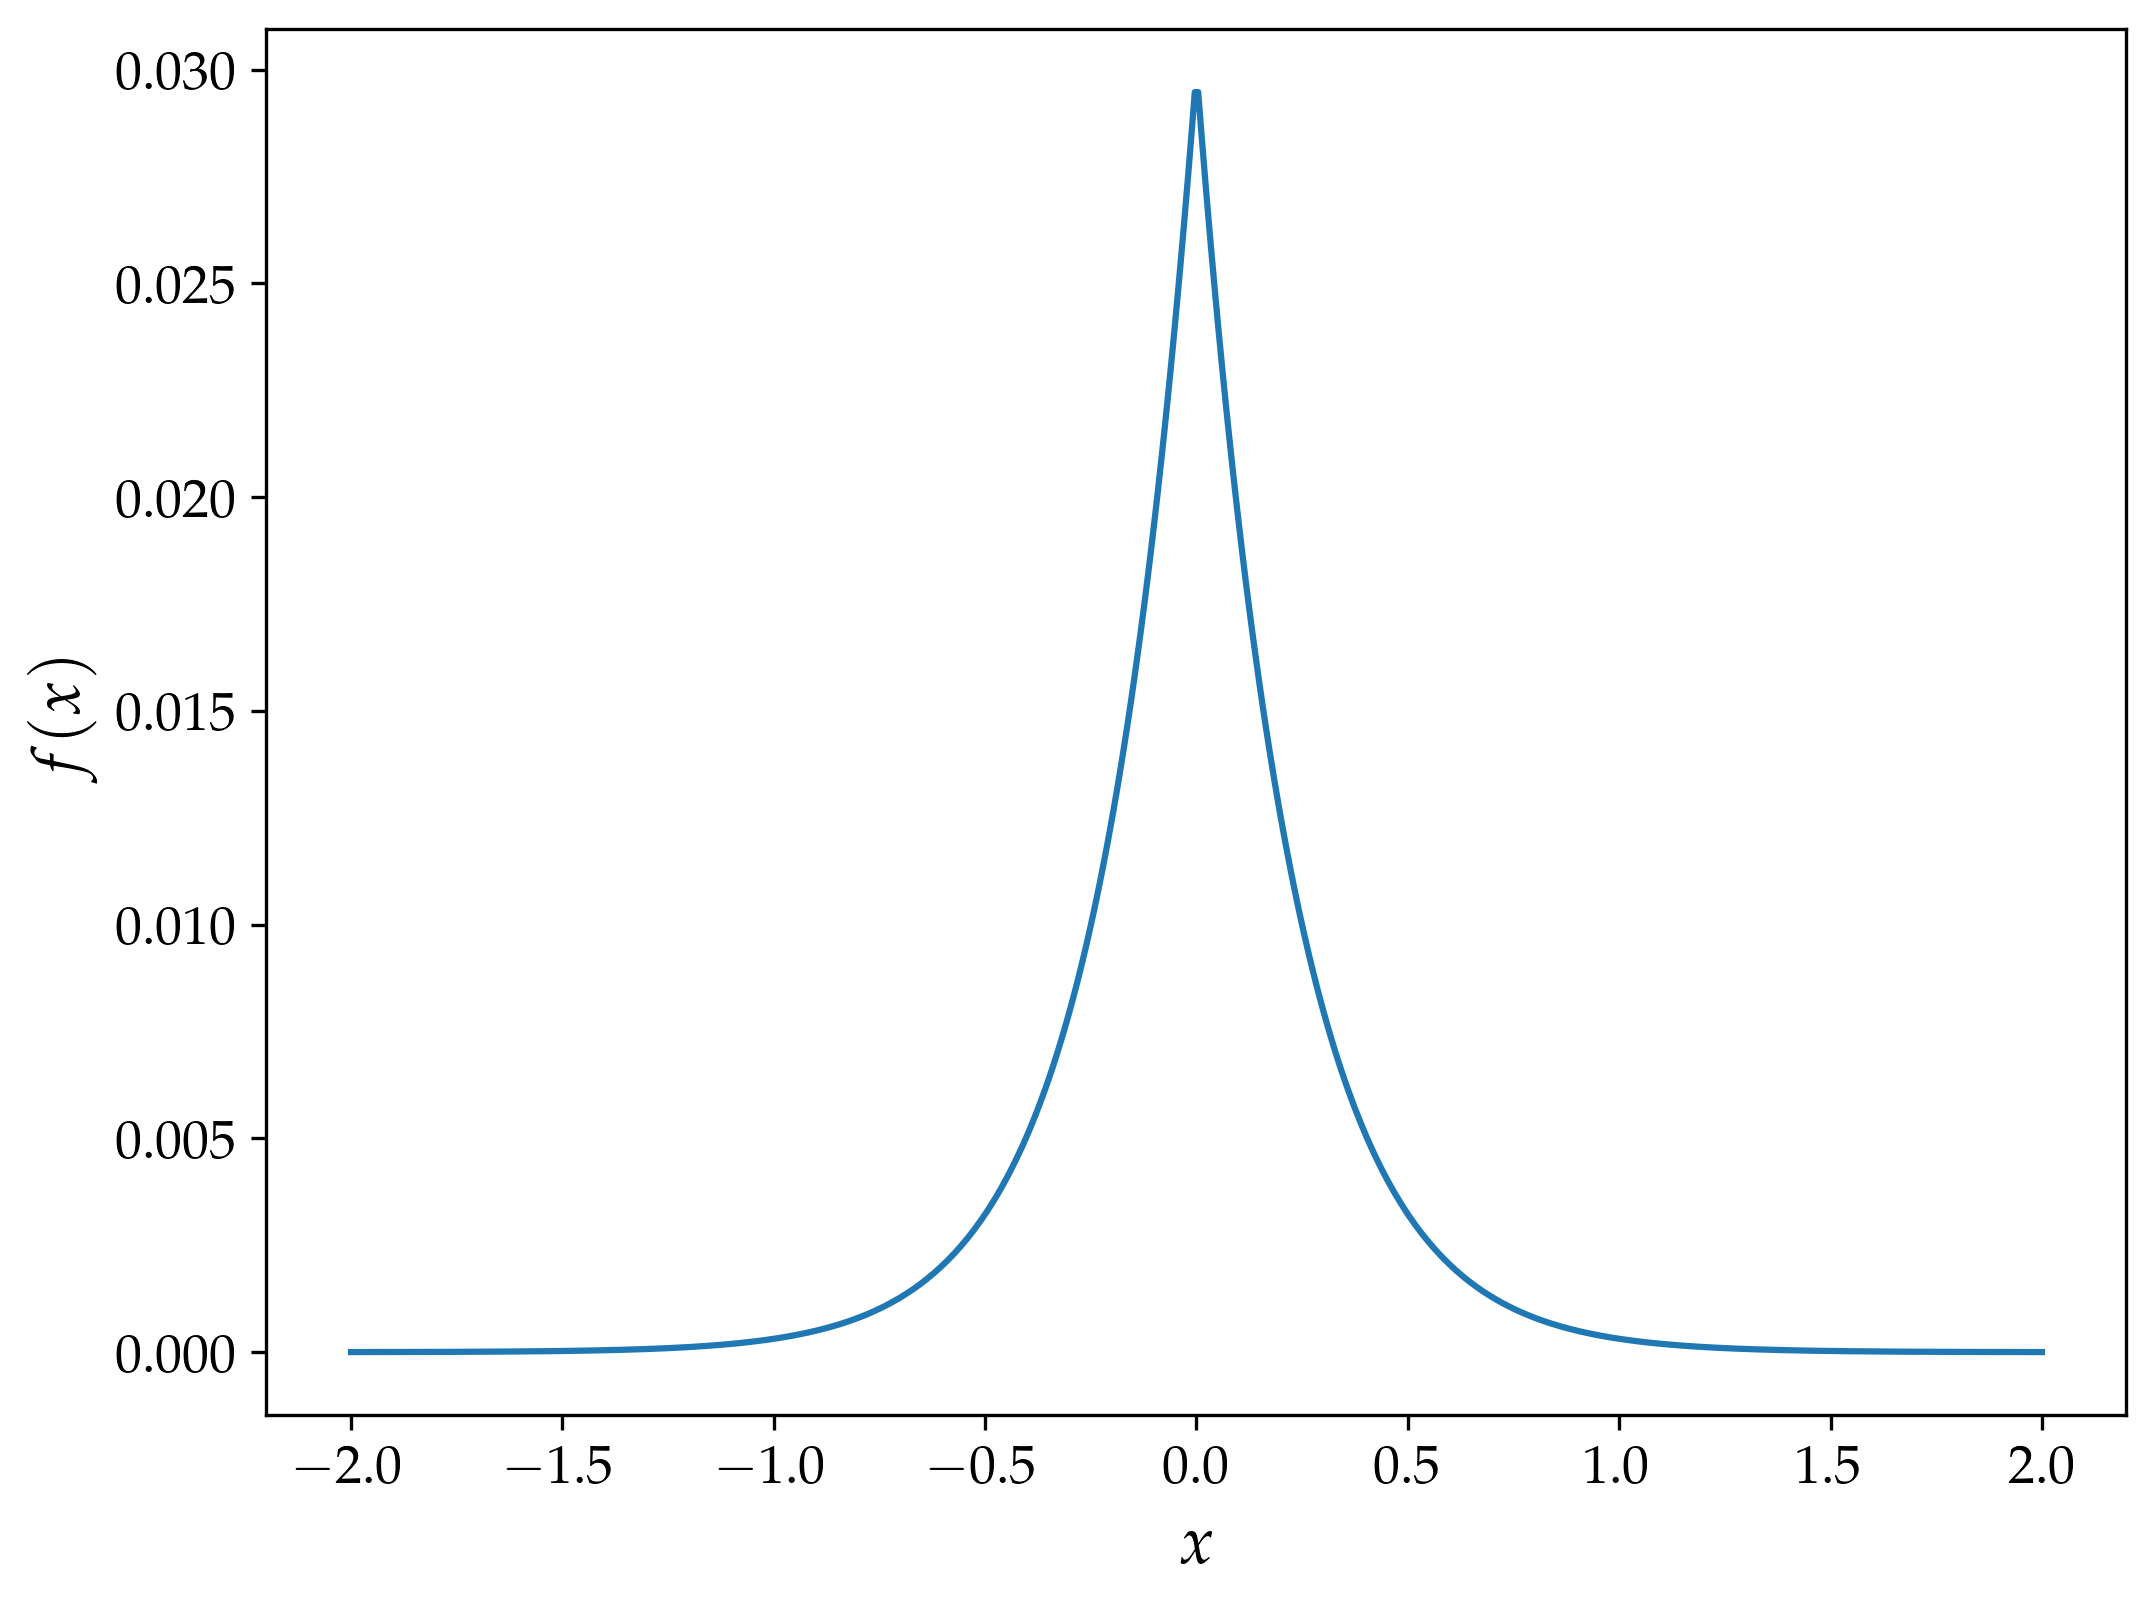

In [518]:
func = lambda x: (np.abs(x)+3)**5 * np.exp(-6*np.abs(x) - 9)
true = 101*np.exp(-9) / 2 

xmax = 2
xcoo = np.linspace(-xmax, xmax, 500)
ycoo = func(xcoo)

plt.plot(xcoo, ycoo)
# plt.yscale('log')
plt.xlabel(rf'$x$')
plt.ylabel(rf'$f(x)$')

plt.savefig('plots/trans_func_display.png')
plt.show()


0.007425295567951541
n --> res:
    5  -->   0.0
       -->   6.2e-03

    7  -->   0.0
       -->   6.2e-03

    9  -->   0.013103915799990191
       -->   6.9e-03

    11 -->   0.0009564345363486343
       -->   5.3e-03

    13 -->   0.007425295567951541
       -->   1.2e-03

    15 -->   0.0007092079971048058
       -->   5.5e-03

    17 -->   0.0031877753454454044
       -->   3.0e-03

    19 -->   -1.6411481667664529e-06
       -->   6.2e-03

    21 -->   4.776471682252119e-09
       -->   6.2e-03



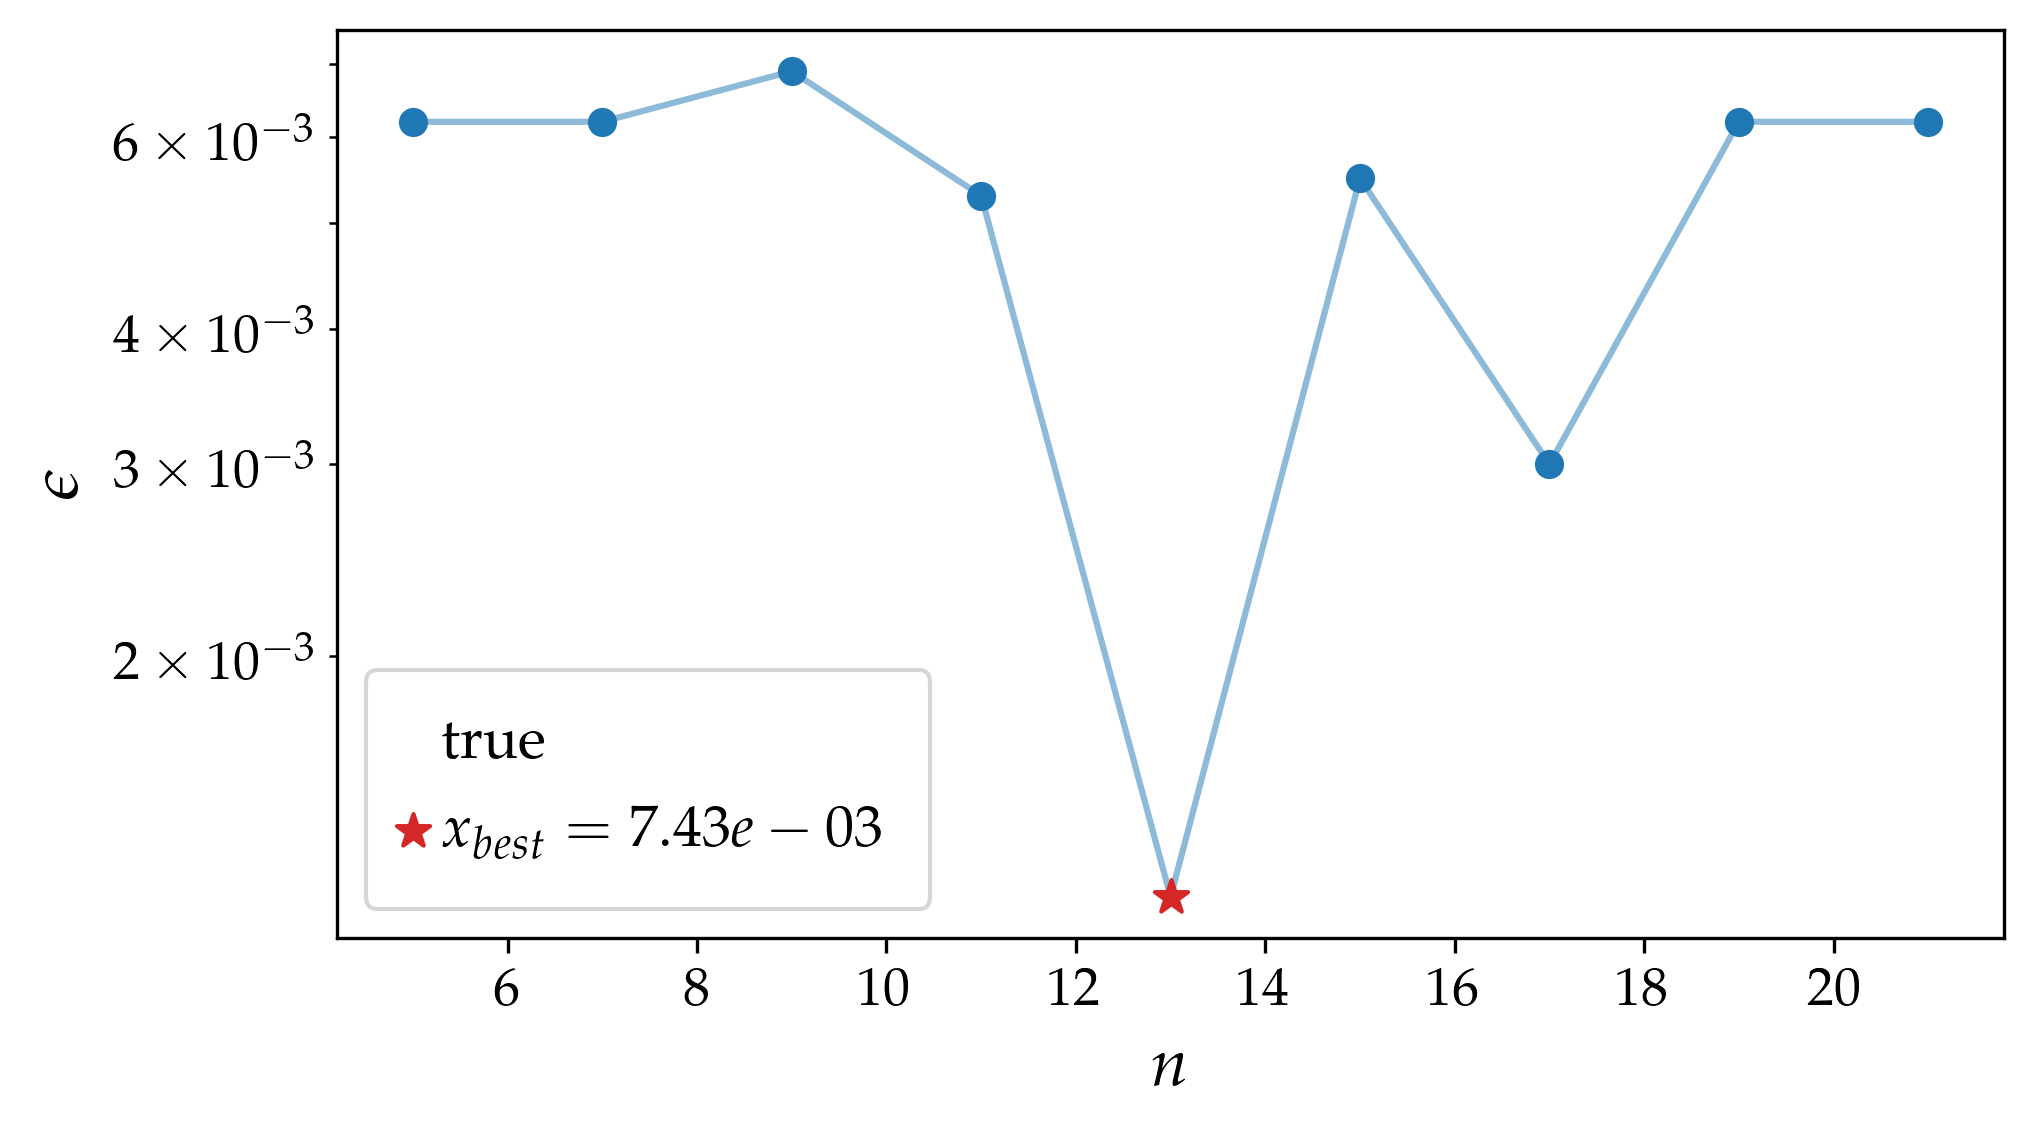

In [538]:
from int_3 import n_deg_3, true_3
from matplotlib.lines import Line2D

data = np.loadtxt('txts/int3.txt')
errs_3 = data[:, 2]
best_ind = np.argmin(data[:, 2])
I_g = data[:, 1][best_ind]
print(I_g)

print('n --> res:')
for row in data:
    deg, res, err = row
    if deg < 10:
        print(f'    {int(deg)}  -->   {res}')
    else:
        print(f'    {int(deg)} -->   {res}')
    print(f'       -->   {err:.1e}\n')


plt.figure(figsize=(7, 4))

line, = plt.plot(n_deg_3, errs_3, alpha=0.5)
pts = plt.scatter(n_deg_3[n_deg_3!=n_deg_3[best_ind]], errs_3[errs_3!=errs_3[best_ind]], marker='o')
best = plt.scatter(n_deg_3[best_ind], errs_3[best_ind], marker='*', 
                   color='C3', zorder=5, s=70)

plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

proxy_true = Line2D([0], [0], color='none')
plt.legend(
    [proxy_true, best], 
    ['true', rf'$x_{{best}} = {I_g:.2e}$'], 
    handlelength=0, 
    handletextpad=0.5,
    borderpad=0.8,       
    frameon=True
)

plt.tight_layout()
plt.savefig('plots/int_3.png')
plt.show()





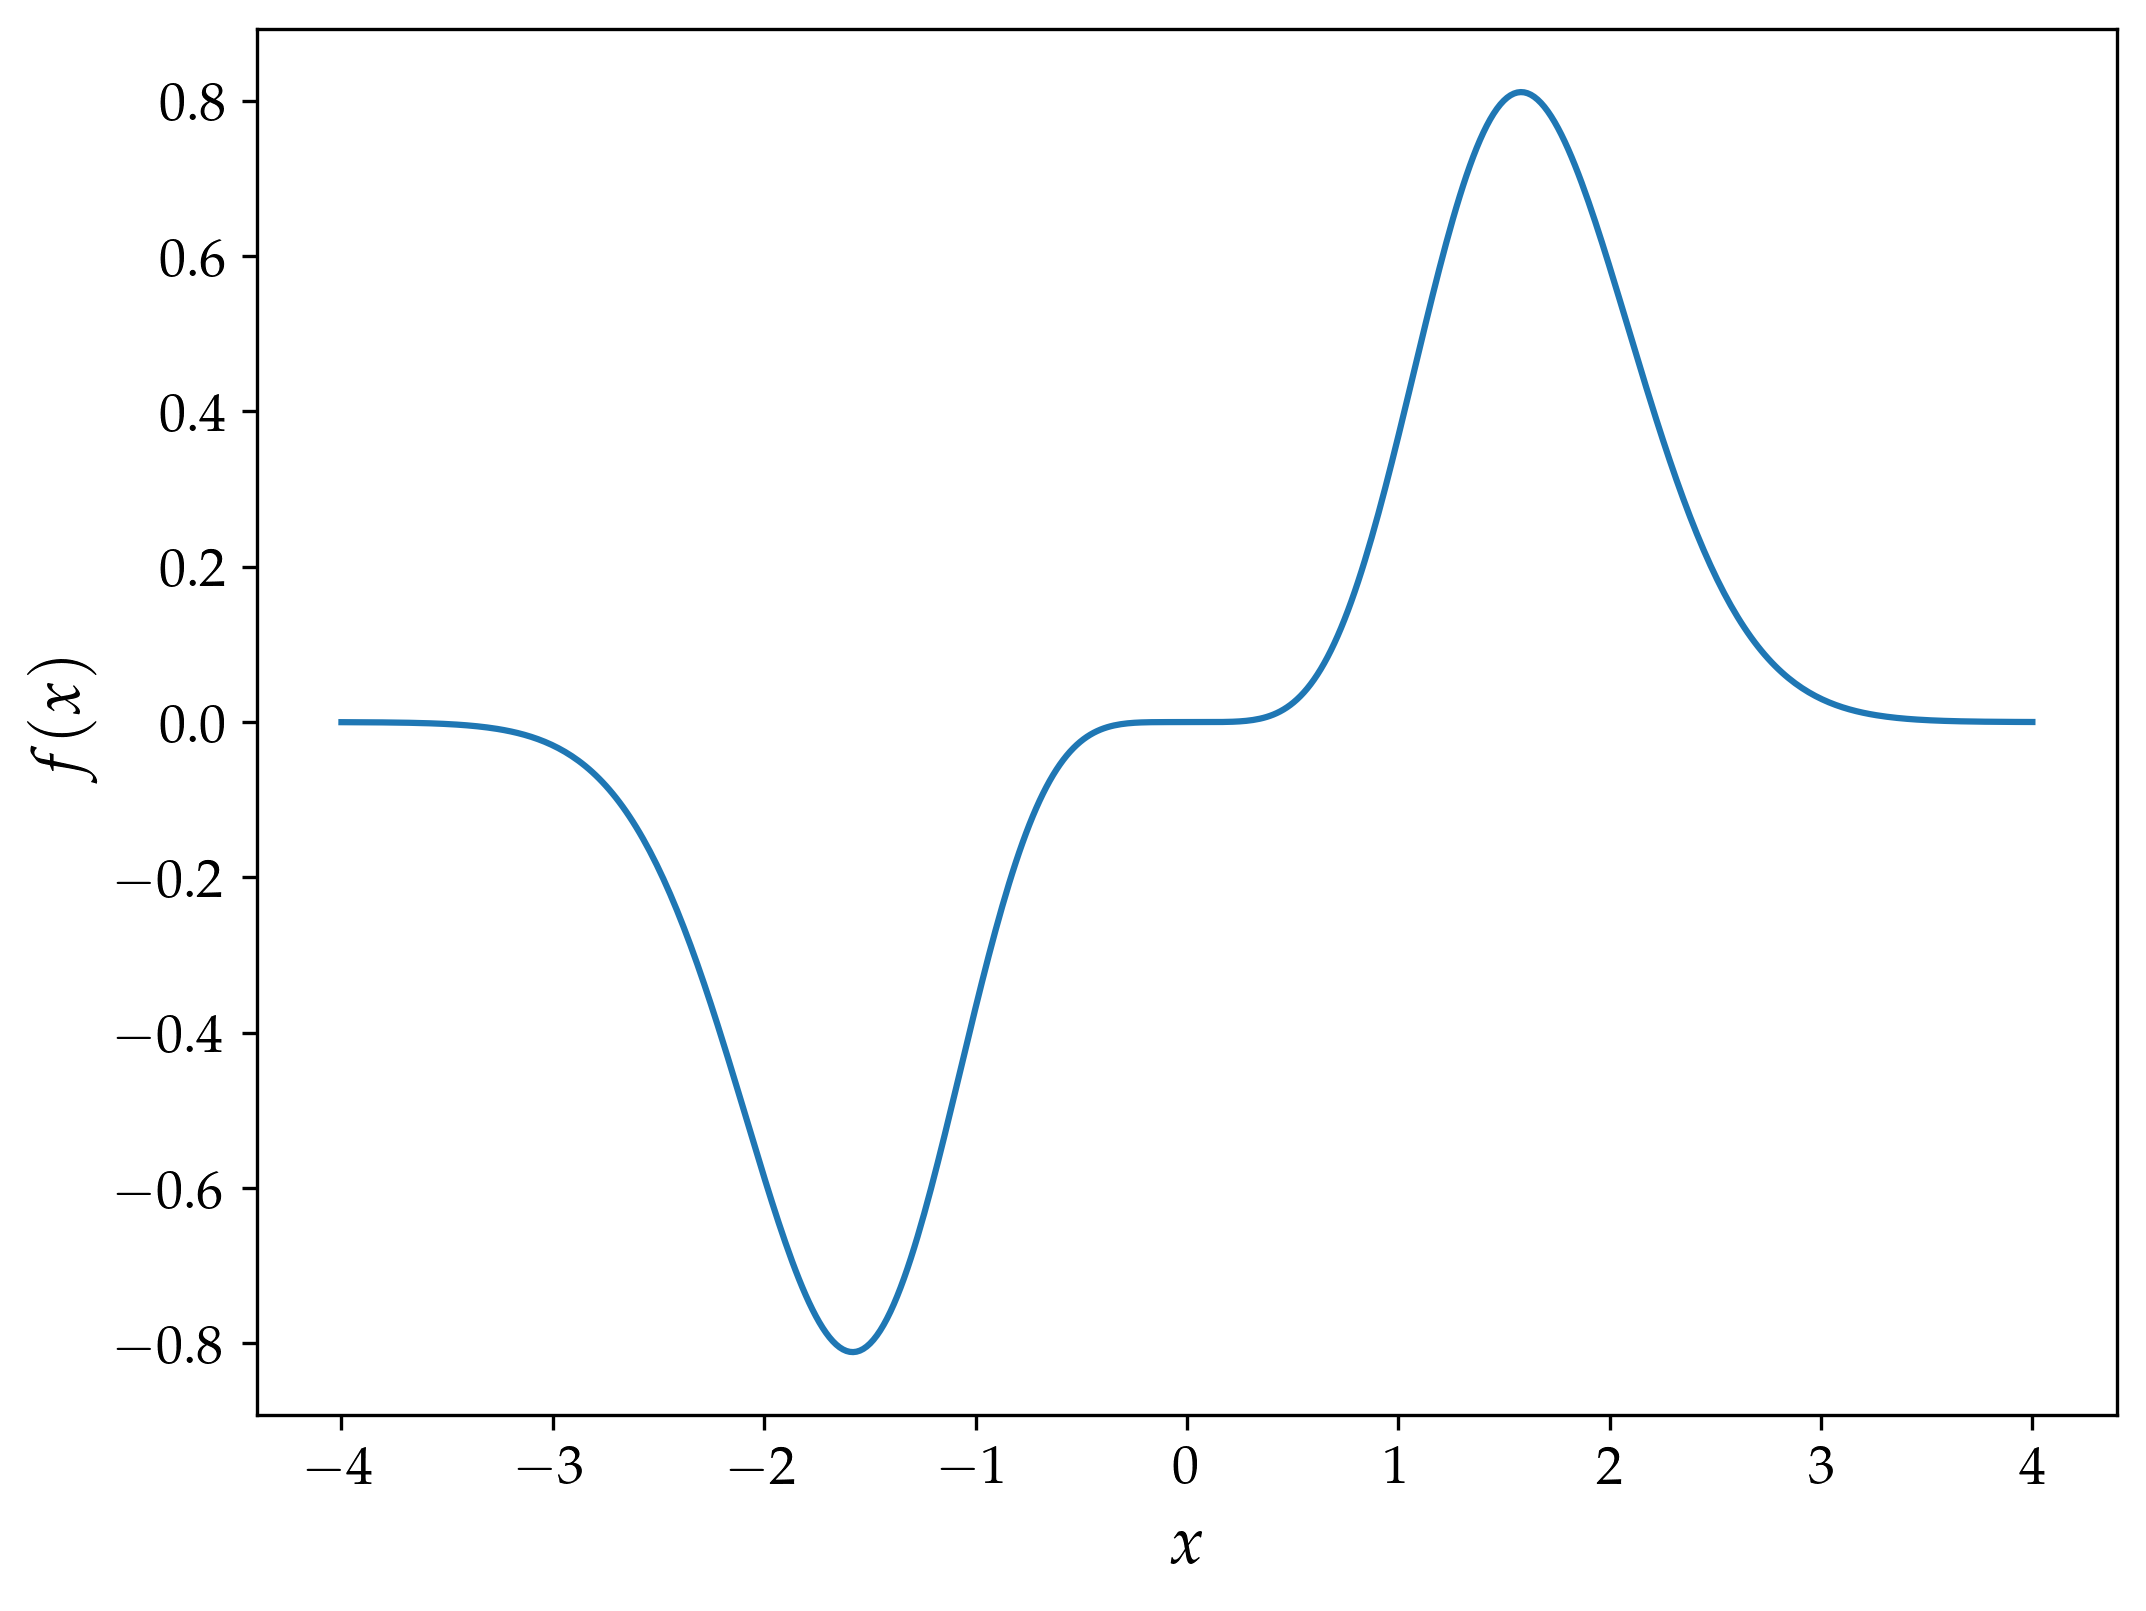

dx = 1.6
dx = 1.1428571428571428
dx = 0.8888888888888888
dx = 0.7272727272727273
dx = 0.6153846153846154
dx = 0.5333333333333333
dx = 0.47058823529411764
dx = 0.42105263157894735
dx = 0.38095238095238093


In [520]:
func = lambda x: x**5 * np.exp(-x**2) 
xmin = 3
xmax = 4
xcoo = np.linspace(-xmax, xmax, 500)
ycoo = func(xcoo)
plt.plot()
plt.plot(xcoo, ycoo)
# plt.yscale('log')
plt.xlabel(rf'$x$')
plt.ylabel(rf'$f(x)$')

plt.savefig('plots/func_display.png')
plt.show()

errs_3_trap = []
errs_3_sim = []

I_t = 0
I_s = 0


for deg in n_deg_3:
    res = trapezoidal(func, xmin, xmax, xmax/ deg)
    print('dx =', 2*xmax/ deg)
    err = abs(res - true)
    errs_3_trap.append(err)
    
    res = Simpson(func, xmin, xmax, xmax/ deg)
    err = abs(res - true)
    errs_3_sim.append(err)
    I_t = res
    I_s = res

names = [
    'Gaussian quadrature',
    'Trapezoidal',
    'Simpson'
]

markers = ['o', '*', 'x']


## **Comparison between methods**

RESULTS OF THE STUDY:
     TRUE                --> I = 0.006232195106377318

     Gauss quadrature    --> I = 0.007425295567951541
     Trapezoidal         --> I = 0.006221976046264583
     Simpson             --> I = 0.006221976046264583



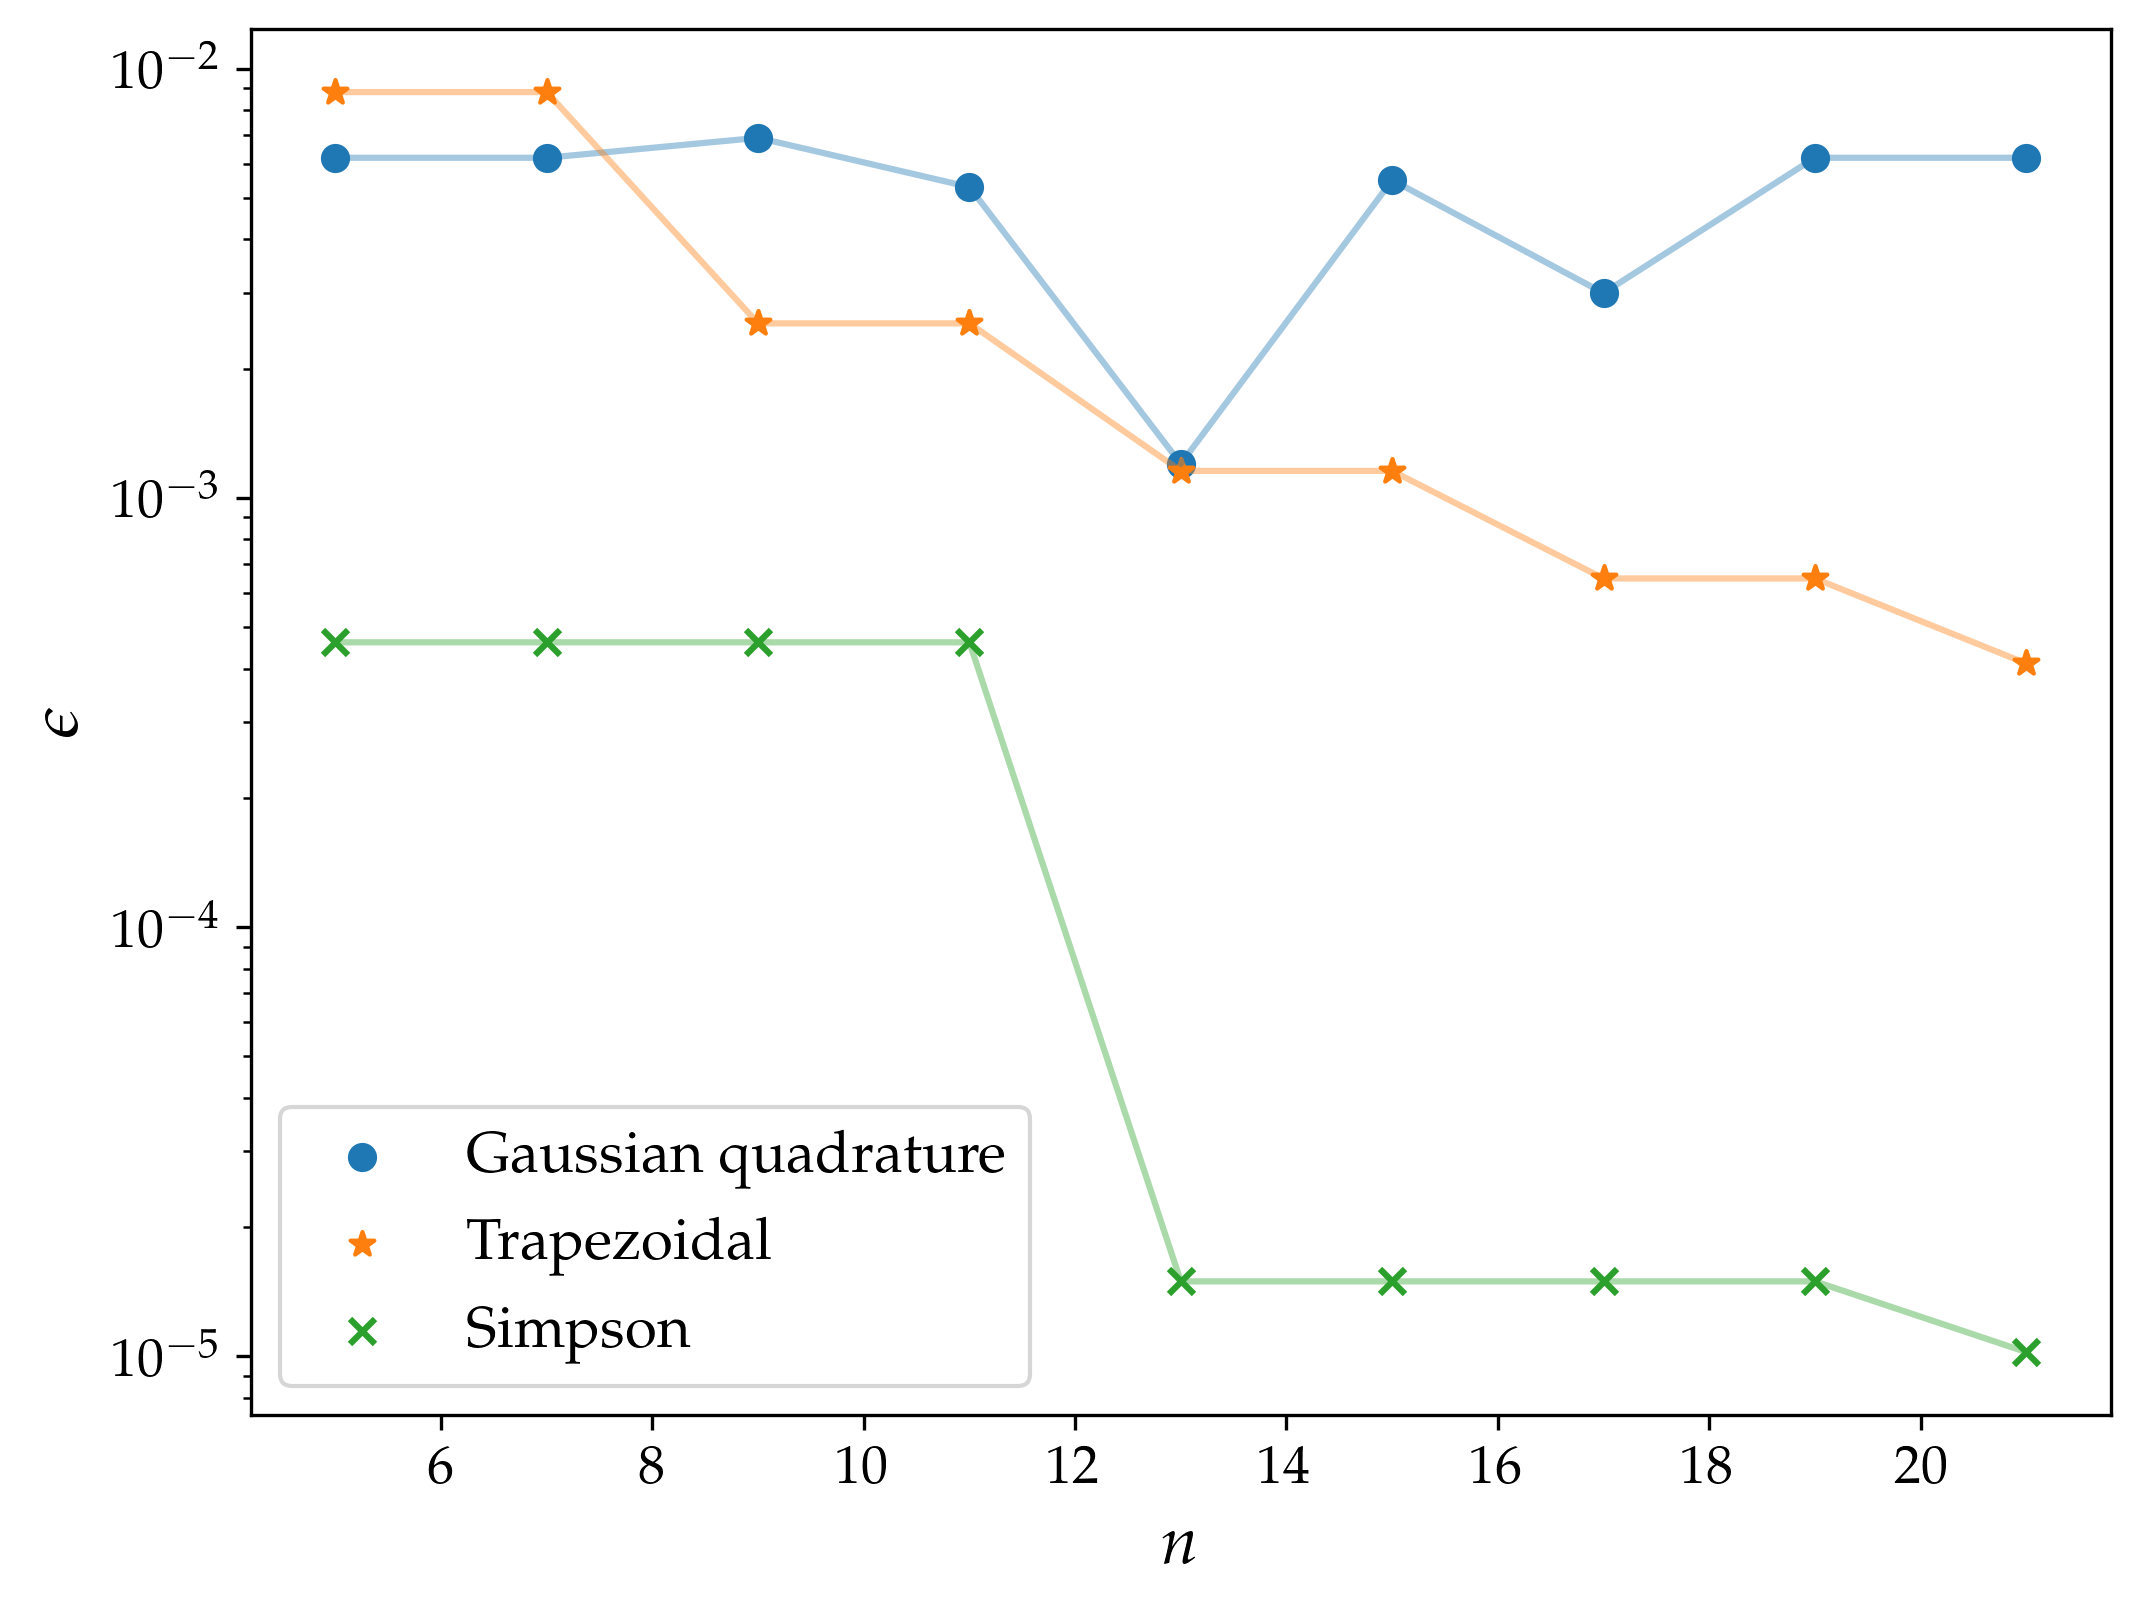

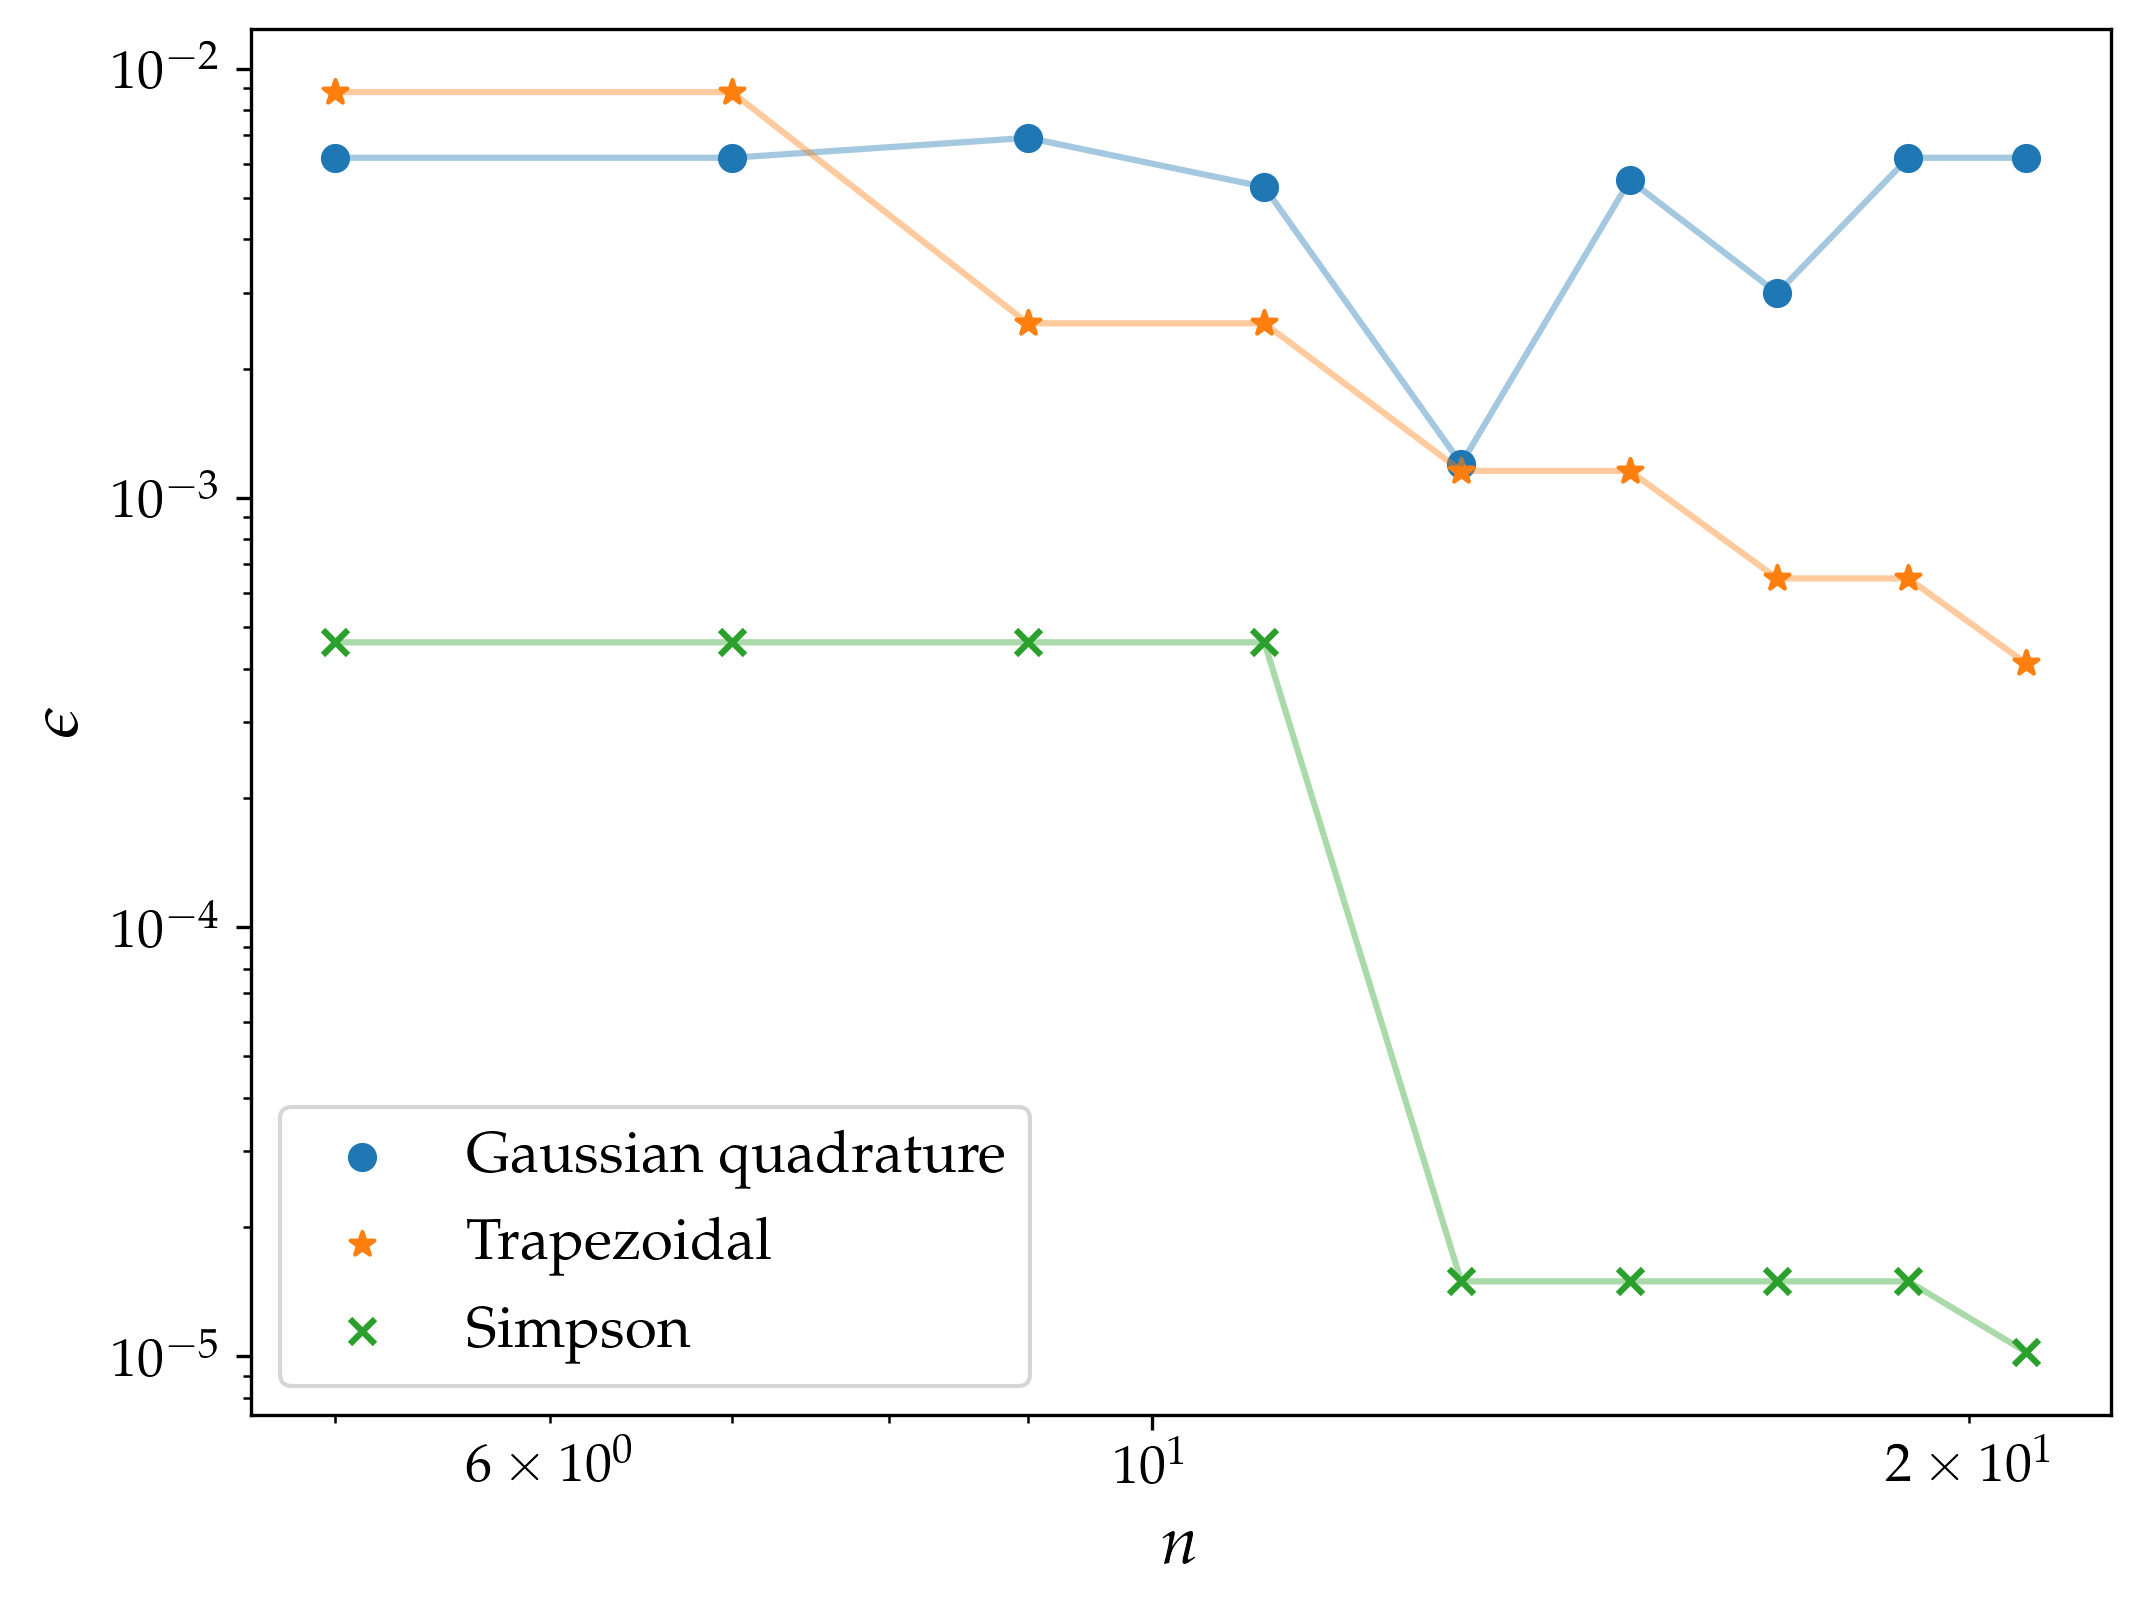

In [521]:
print('RESULTS OF THE STUDY:')
print('     TRUE                --> I =', true_3)
print()
print('     Gauss quadrature    --> I =', I_g)
print('     Trapezoidal         --> I =', I_t)
print('     Simpson             --> I =', I_s)
print()


for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
    plt.plot(n_deg_3, ys, alpha=0.4)
    plt.scatter(n_deg_3, ys, label=names[n], marker=markers[n])
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.legend()

plt.savefig('plots/confr.png')
plt.show()

for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
    plt.plot(n_deg_3, ys, alpha=0.4)
    plt.scatter(n_deg_3, ys, label=names[n], marker=markers[n])
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.xscale('log') 
plt.legend()

plt.savefig('plots/log_confr.png')
plt.show()

## **Fit of the slope of integrals**

In [522]:
# from lib_fitting import lin_fit

# cuts = [(0, -3), (6, -1), (0, -3)]

# for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
#     lin_fit(np.log10(n_deg_3[cuts[n][0]: cuts[n][1]]), np.log10(ys[cuts[n][0]: cuts[n][1]]),
#             name_points=names[n], mar=markers[n], col=f'C{n}', save_name='plots/Fit_'+names[n])

    

c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:583: RuntimeWarning: divide by zero encountered in scalar divide
  dx = Dx / N
c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:605: RuntimeWarning: divide by zero encountered in scalar divide
  dx = Dx / N


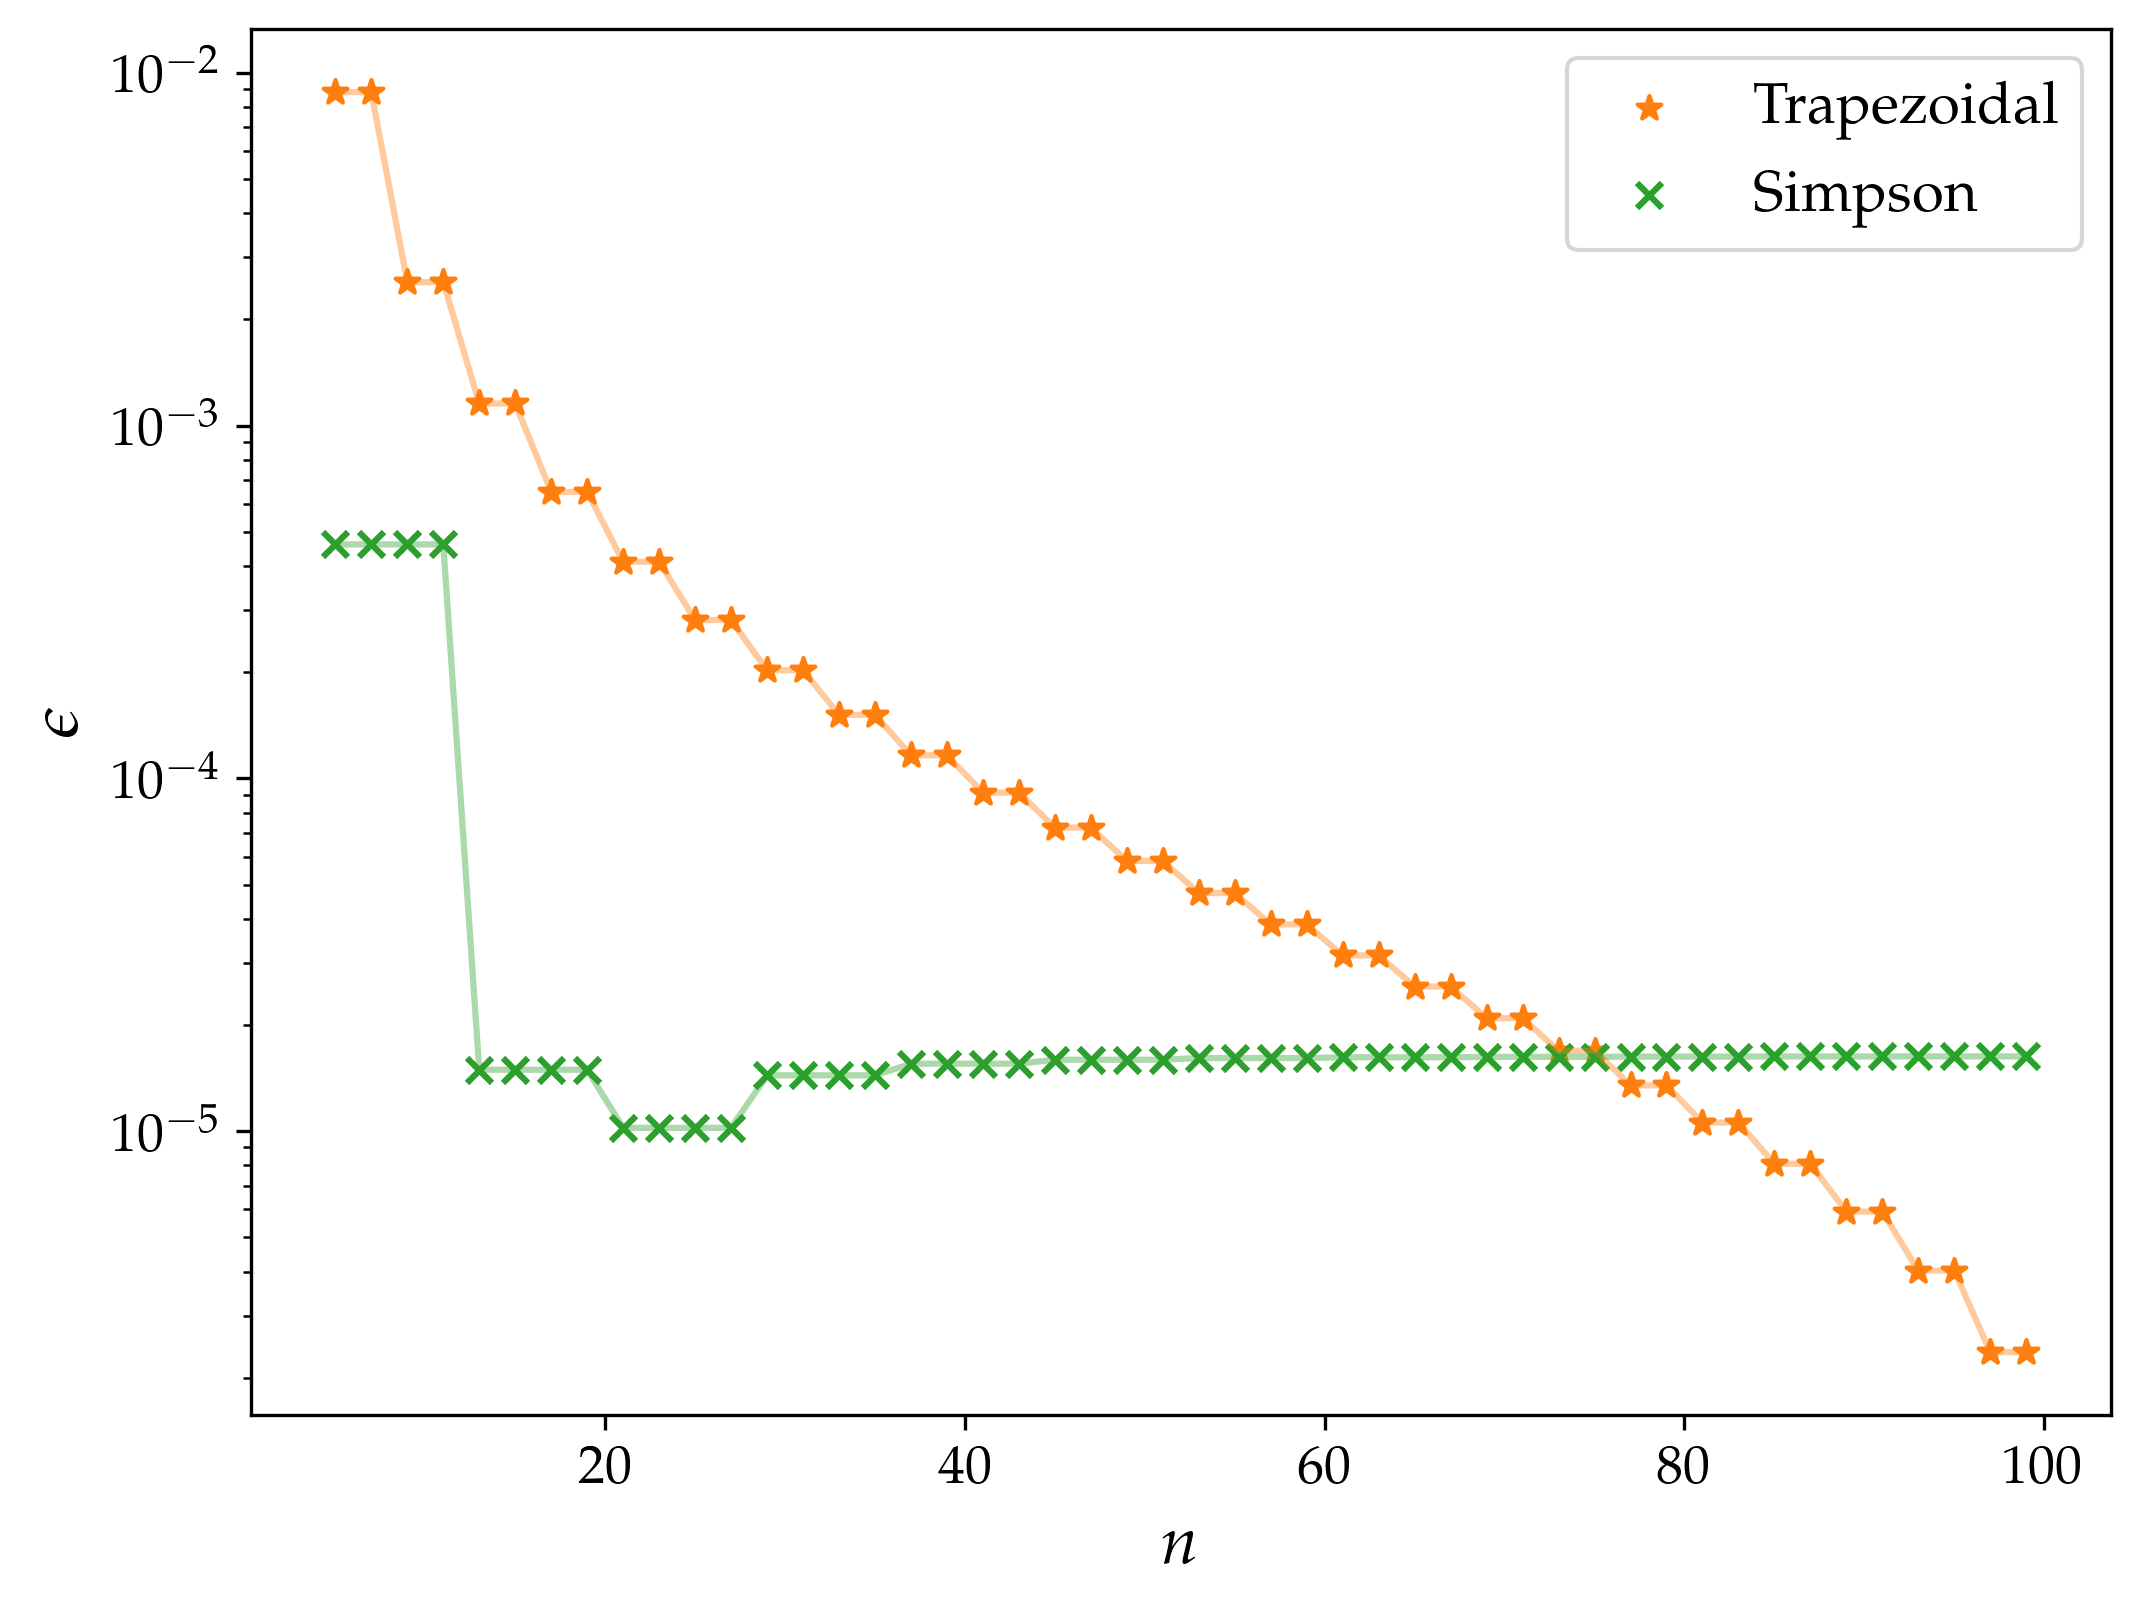

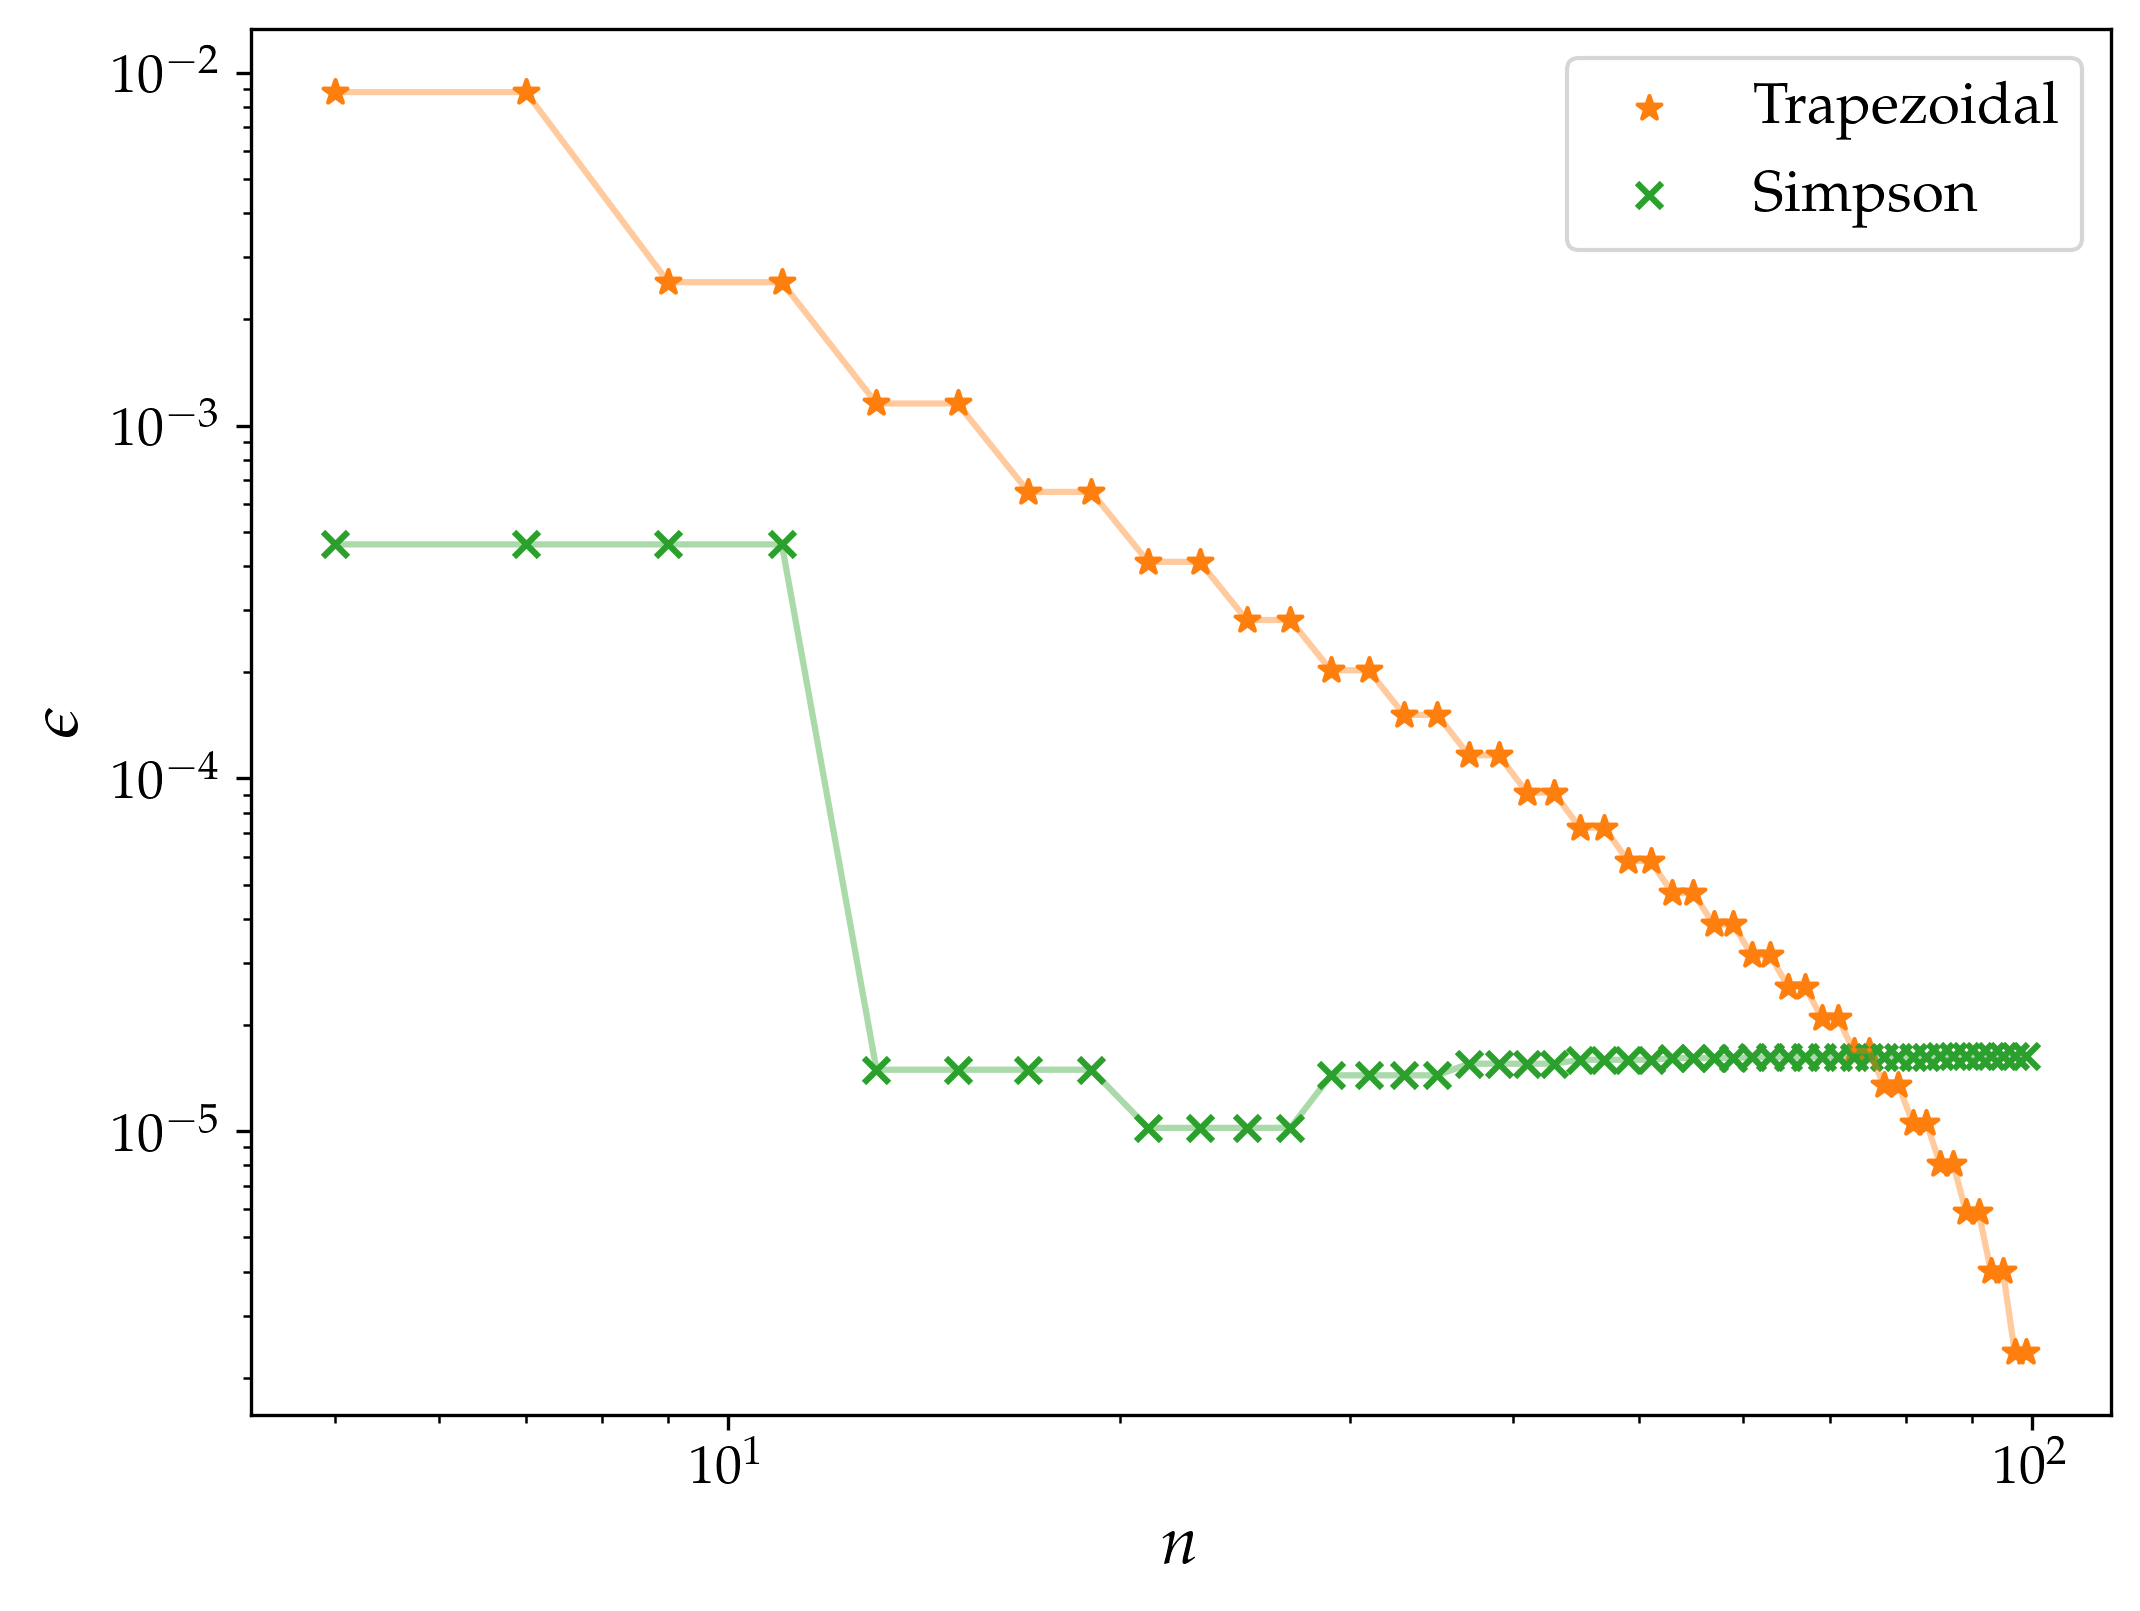

In [523]:

errs_3_trap = []
errs_3_sim = []
n_deg_3_mod = np.arange(1, 100, 2)
for deg in n_deg_3_mod:
    res = trapezoidal(func, xmin, xmax, xmax/ deg)
    err = abs(res - true)
    errs_3_trap.append(err)
    
    res = Simpson(func, xmin, xmax, xmax/ deg)
    err = abs(res - true)
    errs_3_sim.append(err)



for n, ys in enumerate([errs_3_trap, errs_3_sim]):
    plt.plot(n_deg_3_mod, ys, alpha=0.4, color=f'C{n+1}')
    plt.scatter(n_deg_3_mod, ys, label=names[n+1], marker=markers[n+1], color=f'C{n+1}')
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.legend()

plt.show()

for n, ys in enumerate([errs_3_trap, errs_3_sim]):
    plt.plot(n_deg_3_mod, ys, alpha=0.4, color=f'C{n+1}')
    plt.scatter(n_deg_3_mod, ys, label=names[n+1], marker=markers[n+1], color=f'C{n+1}')
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.xscale('log') 
plt.legend()

plt.show()